# ***Automatic Neuron Tracking System for Unconstrained Nematodes (ANTSUN) v2.2.0***

This pipeline takes as input `.nd2` files from the confocal scope corresponding to freely-moving and immobilized recordings for NeuroPAL, together with an `.h5` file from the NIR tracking camera. It processes the confocal data to locate and track neurons in the worm's head, and thereby generates GCaMP traces for these neurons. It also generates the NeuroPAL RGB image used for labeling, labels it with AutoCellLabeler, and maps the labels back to the freely-moving traces. It also processes the NIR data to extract behavioral variables that can be correlated with the calcium traces.

The expected runtime of this pipeline is 34 hours.


## General notes

### GPU acceleration

Many steps of `ANTSUN` are GPU-accelerated (they are labeled as such beforehand). Thus, you need to ensure that there is sufficient GPU memory on your device before running those steps. It is recommended to have at least 8GB available before running any GPU-accelerated step. You can view how much GPU memory is available by running `nvidia-smi`.

- On `flv-c1`, there is only one GPU with 8GB memory. ANTSUN will likely fail as this is not enough memory.
- On `flv-c2`, there are four GPUs, two with 16GB memory each and two with 24GB each.
- On `flv-c3`, there are four GPUs, three with 24GB memory each and one with 48GB.
- On `flv-c4`, there are four GPUs, each with 48GB.

If you're using a server with more than one GPU, you can specify which one to use (according to its index in `nvidia-smi` by setting `nvidia_smi_device` and `flv_c` appropriately). Please reserve the GPU using our [GPU reservations sheet](https://docs.google.com/spreadsheets/d/1wMQ_bGJly15_1CXspK0fWzs-bd-lF-tVMpOVZZZ6SAc/edit?gid=922051617#gid=922051617).

**Please restart the kernel after the notebook is done running.**

### Error recovery

If a step of the pipeline encounters an unexpected error, it is usually advisable to restart the kernel. **WARNING:** Restarting the kernel while save operations are in progress could corrupt the data files and possibly mean you would have to start over from the very beginning. Thus, before restarting the kernel, you should check that `JLD2` files are not actively being saved, and only restart the kernel once the pipeline is on a step other than saving them.

After you restart the kernel, rerun the "Load packages", "Data parameters" and "Initialize data dictionaries" steps of the pipeline. This should reset the pipeline into its last usable state. If the error was due to running out of memory or some other hardware issue, assuming there are computing resources available, you should then be able to run the pipeline from the step that generated the error through the end.

If the error was due to you making a mistake in the "Data parameters" section of the pipeline, you may need to rerun the "Pipeline parameters" and "Save parameter settings" sections of the notebook after running the "Initialize data dictionaries" step, but note that you should **not** rerun the "Read meta-parameters from the ND2 file" step.

In [1]:
nvidia_smi_device = 2
flv_c = 3

3

In [2]:
if flv_c == 1
    gpu_device = 0
elseif flv_c == 2
    if nvidia_smi_device < 2
        gpu_device = nvidia_smi_device + 2
    else
        gpu_device = nvidia_smi_device - 2
    end
elseif flv_c == 3
    if nvidia_smi_device < 2
        gpu_device = 1 - nvidia_smi_device
    else
        gpu_device = nvidia_smi_device
    end
else
    error("Unsupported flv-c version")
end 
gpu_device

2

In [3]:
ENV["CUDA_VISIBLE_DEVICES"] = "$(gpu_device)"

"2"

## Load packages

In [4]:
# Flavell lab packages
using ND2Process
using GPUFilter
using WormFeatureDetector
using NRRDIO
using FlavellBase
using SegmentationTools
using ImageDataIO
using RegistrationGraph
using ExtractRegisteredData
using CaAnalysis
using BehaviorDataNIR
using UNet2D
using ImageRegistration

# Other packages
using ProgressMeter
using PyCall
using PyPlot
using Statistics
using StatsBase
using DelimitedFiles
using Images
using Cairo
using Distributions
using DataStructures
using HDF5
using Interact
using WebIO
using Plots
# using GraphPlot
# using LightGraphs
# using SimpleWeightedGraphs
using Dates
using JLD2
using TotalVariation
using VideoIO
using Distributions
using MultivariateStats
using FFTW
using LinearAlgebra
using GLMNet
using InformationMeasures
using CUDA
using LsqFit
using Optim
using Rotations
using CoordinateTransformations
using ImageTransformations
using Interpolations
using H5Zblosc

using Distributed

┌ Warning: You are using a non-official build of Julia. This may cause issues with CUDA.jl.
│ Please consider using an official build from https://julialang.org/downloads/.
└ @ CUDA ~/.julia/packages/CUDA/75aiI/src/initialization.jl:180


WebIO._IJuliaInit()

2024-11-20 17:22:36.915199: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-11-20 17:22:36.915286: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-11-20 17:22:36.916793: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-11-20 17:22:36.923319: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-11-20 17:22:37.640193: W tensorflow/compiler/tf2

# Parameter settings

Expected runtime: 1 minute

### Data parameters

This section includes dataset-specific parameters, including the filename, voxel spacing, laser intensity step-up, and channel identities. It must be run every time you initialize the pipeline. 

**Important:** If you already have dictionaries saved and are rerunning the pipeline, skip to "Initialize Data Dictionaries" after running this section, and do not rerun the "Pipeline parameters" section unless you have modified something here.

In [5]:
## ND2 parameters
ch_bluegreen = 1 # GCaMP and BFP
ch_red = 2 # mNeptune
n_rec = 1 # number of Illumination Sequence module recordings (.nd2) in the HDF5 file 
h5_confocal_time_lag = 0 # if this is the second confocal dataset using the same h5 file, set equal to number of frames in 1st dataset
spacing_lat = 0.54 # Spacing of each voxel in the xy plane. If different, it will likely be necessary to modify pipeline parameters.
spacing_axi = 0.54 # Spacing of each voxel in the z dimension. If different, it will likely be necessary to modify pipeline parameters.
n_z = 80 # Number of z-slices per z-stack
z_range = 4:80 # Which z-slices to use. We exclude the first three due to piezo motion artifacts.

## Server parameter
# data_dir = "/store1"
data_dir = "/data1"
server_dir = (flv_c == 3) ? "/data3" : "/data1"

## Freely-moving parameters
max_graph_num = 800 # time point just before laser intensity is changed in freely-moving dataset. If not changed, set to length of the dataset.
blue_laser = [13,15] # array of blue laser values before vs after param["max_graph_num"] in the freely-moving dataset
green_laser = [15,17] # array of green laser values before vs after param["max_graph_num"] in the freely-moving dataset


## Data path parameters
prj = "panneuralGFP" # change to your project - ie: the location to save the data
path_raw_data = "/data1/shared/$(prj)/data_raw/2024-07-17" # change to the directory with all raw data files

datasets = Dict() # for each filter, update the corresponding entry in the dictionary the path to the ND2 file for that dataset (without the .nd2 extension)
datasets["freely_moving"] = "2024-07-17-01"
datasets["all_red"] = "2024-07-17-02"
datasets["mNeptune"] = "2024-07-17-03"
datasets["OFP"] = "2024-07-17-04"
datasets["BFP"] = "2024-07-17-05"

## You should not need to change anything below this line except possibly `reg_timepts[dataset] = 30`.
datasets_freely_moving = ["freely_moving"] # freely-moving datasets
dataset_central = "freely_moving" # central dataset - register other datasets to this. Must contain camera-alignment registration
datasets_register = ["all_red"] # datasets to register back to central dataset
dataset_immobilized_central = "all_red" # dataset to register immobilized datasets to, for NeuroPAL
@assert(dataset_immobilized_central in datasets_register, "Immobilized dataset must be registered to freely moving")

n_timepts_merge = Dict() # number of registrations to attempt back to the central dataset, for each registered dataset
for dataset in datasets_register
    n_timepts_merge[dataset] = 200
end

## Immobilized parameters
reg_timepts = Dict()
for dataset in keys(datasets)
    if dataset in datasets_freely_moving
        continue
    end
    reg_timepts[dataset] = 30 # timepoint to register everything to, for the immobilized datasets
end


rotate_img_x = false # whether to rotate the image about the x-axis (if the worm was put on the slide the wrong way)

fm = datasets["freely_moving"]
path_root_process_freelymoving = "$(data_dir)/shared/$(prj)/data_processed_220/$(fm)_output"
path_root_process_immobilized = "$(data_dir)/shared/$(prj)/data_processed_220/$(fm)_output/neuropal"

create_dir(path_root_process_freelymoving)
create_dir(path_root_process_immobilized)

In [6]:
param_paths = Dict()
params = Dict()
data_dicts = Dict()
error_dicts = Dict();

### Pipeline parameters

This section includes parameters that influence how the pipeline will process the data. They are mostly heuristic parameters that can be tuned for optimal performance, as well as some parameters that change OpenMind compute settings. These are likely safe to leave as default unless you have significantly changed the data structure.

Also sets default file name parameters, which specify where intermediate parameters and outputs of the pipeline will be stored. It is generally not advised to change them.

Note that the first time you set up the pipeline, you will need to change the following entries to point to your files instead of Adam's:

- `param_path["path_unet_pred"]` should point to your `pytorch-3dunet` installation
- `param_path["path_unet_py_env"]` should point to the python environment corresponding to your `pytorch-3dunet` installation (usually Julia's `conda` environment)
- `param_path["path_dir_lock"]` should point to a lock directory (you need to make this directory if it doesn't exist)
- `om_user` should be your OpenMind username (kerberos)

Most pipeline parameters are stored in the dictionaries `param` and `param_path`. For useful functions for interacting with these dictionaries, see https://flavell-lab.github.io/ImageDataIO.jl/stable/.

In [7]:
for dataset in keys(datasets)
    exp_prefix = datasets[dataset]
    if dataset in datasets_freely_moving
        path_root_process = path_root_process_freelymoving
    else
        path_root_process = joinpath(path_root_process_immobilized, datasets[dataset])
    end
    
    if !(dataset in keys(params))
        params[dataset] = Dict()
    end
    param = params[dataset]
    
    if !(dataset in keys(param_paths))
        param_paths[dataset] = Dict{String,Any}()
    end
    param_path = param_paths[dataset]

    param_path["path_root_process"] = path_root_process

    param_path["path_log_file"] = joinpath(path_root_process, "log_progress.txt")
    param_path["path_unet_pred"] = "/home/candy/src/pytorch-3dunet/pytorch3dunet/predict.py" # Path to the pytorch-3dunet installation on the local machine
    param_path["path_unet_param"] = "$(server_dir)/shared/dl_weights/3dunet_NeuroPAL/instance_segmentation_test.yaml" # Path to the UNet parameter file
    param_path["path_unet_py_env"] = "/home/candy/.julia/conda/3/x86_64/bin/activate" # Path to a script that should be run to configure environment variables for the pytorch-3dunet
    param_path["path_transformix"] = (flv_c == 2) ? "/bin/transformix" : "/usr/local/bin/transformix" # Path to transformix executable on the LOCAL machine
    param_path["path_elastix_local"] = (flv_c > 1) ? "/bin/elastix" : "/usr/local/bin/elastix" # Path to elastix executable on the LOCAL machine

    
    param_path["path_head_unet_model"] = "/data1/shared/head_detector_0124/head_detector_0124/unet2d-head-detector/unet2d-head-detector_best.pt" # path to head detection unet model
    param_path["path_2d_unet_param"] = "$(server_dir)/shared/dl_weights/behavior_nir/worm_segmentation_best_weights_0310.pt"

    param_path["path_dir_lock"] = "/home/candy/lock" # path to lock directory

    if dataset in datasets_freely_moving
        param_path["path_head_rotate"] = "/om2/group/flavell/script/registration/euler_registration/euler_head_rotate.py"
    else
        param_path["path_head_rotate"] = nothing
    end
    param_path["path_head_rotate_activity_marker"] = nothing
    param_path["path_elastix"] = "/om2/user/aaatanas/elastix-5.0.1/build/bin/elastix"
    param_path["path_run_elastix"] = "/om2/group/flavell/script/registration/run_elastix_command.sh"

    om_user = "dikang" # Your username on OpenMind
    param_path["path_om_home"] = "/om2/user/$om_user"
    param_path["path_om_env"] = "/home/$(om_user)/.bashrc" # path to user environment variable script on OpenMind
    param_path["path_om_data"] = joinpath(param_path["path_om_home"], "$(exp_prefix)_output")
    param_path["path_om_home_scripts"] = "/om2/user/$om_user"
    param_path["path_om_scripts"] = joinpath(param_path["path_om_home_scripts"], "$(exp_prefix)_output")

    param_path["path_om_euler_param"] = "/om2/group/flavell/script/registration/elastix_parameters/parameters_freely_moving_euler.txt" # Path to Euler parameter file on OpenMind
    param_path["path_om_euler_am_param"] = "/om2/group/flavell/script/registration/elastix_parameters/parameters_freely_moving_euler_output.txt" # Path to Euler parameter file on OpenMind
    param_path["path_om_affine_param"] = "/om2/group/flavell/script/registration/elastix_parameters/parameters_freely_moving_affine.txt" # Path to Affine parameter file on OpenMind
    
    if dataset in datasets_freely_moving
        param_path["path_om_bspline_param"] = "/om2/group/flavell/script/registration/elastix_parameters/parameters_freely_moving_bspline.txt" # Path to BSpline parameter file on OpenMind
        param["max_graph_num"] = max_graph_num # maximum length before graph split
        param["blue_laser"] = blue_laser
        param["green_laser"] = green_laser
        
        param["blue_zero_thresh"] = 4.5
        param["blue_min_laser"] = 5.2
        param["blue_max_interpolate"] = 2.0

        param["green_zero_thresh"] = 7.0
        param["green_min_laser"] = 7.7
        param["green_max_interpolate"] = 2.0

        intensity = h5read("$(server_dir)/shared/2022-05-11-laser-power.h5", "488nm/1/intensity")
        laser_perc = h5read("$(server_dir)/shared/2022-05-11-laser-power.h5", "488nm/1/laser_percent")

        intensity2 = h5read("$(server_dir)/shared/2022-05-11-laser-power.h5", "488nm/2/intensity")
        laser_perc2 = h5read("$(server_dir)/shared/2022-05-11-laser-power.h5", "488nm/2/laser_percent")
        
        param["blue_laser_intensity"] = (intensity .+ intensity2) ./ 2
        param["blue_laser_perc"] = laser_perc

        param["green_laser_intensity"] = h5read("$(server_dir)/shared/2022-05-11-laser-power.h5", "561nm/1/intensity")
        param["green_laser_perc"] = h5read("$(server_dir)/shared/2022-05-11-laser-power.h5", "561nm/1/laser_percent");
        
        param["good_registration_resolutions"] = [(0,0)] #= which registration resolutions
            are good enough to extract data from =#
        param["reg_n_resolution"] = [0,0,4]

        param["good_registration_resolutions_to_immobilized"] = [(2,0),(2,1),(2,2),(2,3)]

        @assert(laser_perc == laser_perc2)
        
        # NeuroPAL labeling settings
        param_path["path_root_process_label"] = joinpath(path_root_process, "neuropal_label")
        create_dir(param_path["path_root_process_label"])
        param_path["path_neuropal_img"] = joinpath(param_path["path_root_process_label"], "NeuroPAL.nrrd")
        #param_path["path_neuropal_img_mNeptune_GCaMP"] = joinpath(param_path["path_root_process_label"], "NeuroPAL_mNeptune_GCaMP_bleedthrough.nrrd")
        param_path["path_bfp_img"] = joinpath(param_path["path_root_process_label"], "BFP.nrrd")
        param_path["path_ofp_img"] = joinpath(param_path["path_root_process_label"], "OFP.nrrd")
        param_path["path_gcamp_img"] = joinpath(param_path["path_root_process_label"], "OFP_GCaMP.nrrd") # actual GCaMP
        param_path["path_mNeptune_img"] = joinpath(param_path["path_root_process_label"], "mNeptune.nrrd")
        #param_path["path_mNeptune_gcamp_img"] = joinpath(param_path["path_root_process_label"], "mNeptune_GCaMP_bleedthrough.nrrd") # GCaMP bleedthrough
        param_path["path_all_red_img"] = joinpath(param_path["path_root_process_label"], "all_red.nrrd")
        param_path["path_neuron_img"] = joinpath(param_path["path_root_process_label"], "neuron_rois.nrrd")
        param_path["path_dir_autolabel_input"] = joinpath(param_path["path_root_process_label"], "autolabel_data")
        param_path["path_h5_autolabel_input"] = joinpath(param_path["path_dir_autolabel_input"], "NeuroPAL.h5")
        param_path["path_neuron_img_crop"] = joinpath(param_path["path_root_process_label"], "neuron_rois_cropped.h5")
        param_path["path_autolabel_csv"] = joinpath(param_path["path_root_process_label"], "labels.csv")
        param_path["path_autolabel_param"] = "/data3/shared/dl_weights/NeuroPAL_autolabel_release/v2/instance_segmentation_test.yaml"
        param_path["path_autolabel_neuron_ids"] = "/data3/shared/dl_weights/NeuroPAL_autolabel_release/v2/extracted_neuron_ids.h5"

        # Deepnet registration settings
        np = pyimport("numpy")

        param_path["path_dir_roi_watershed_recropped"] = joinpath(param_path["path_root_process"], "img_roi_watershed")
        param_path["path_dir_ch1_recropped"] = joinpath(param_path["path_root_process"], "ch1_recropped")
        param_path["path_dir_ch1_registered"] = joinpath(param_path["path_root_process"], "ch1_registered")
        param_path["path_deepreg_weights"] = "/data3/shared/dl_weights/deepreg/large_crop/centroid_labels_augmented_batched_hybrid/ckpt-287"
        param_path["path_deepreg_config"] = "/data3/shared/dl_weights/deepreg/large_crop/config.yaml"
        
        param_path["path_dir_nrrd_filt_recropped"] = joinpath(param_path["path_root_process"], "NRRD_filtered")
        create_dir(param_path["path_dir_nrrd_filt_recropped"])

        param["deepreg_batch_size"] = 3
        if flv_c == 4
            param["deepreg_batch_size"] = 6
        end
        if flv_c == 3 && nvidia_smi_device == 1
            param["deepreg_batch_size"] = 6
        end
        if flv_c == 2 && nvidia_smi_device < 2
            param["deepreg_batch_size"] = 2
        end
        param["deepreg_label_size"] = (200, 3)
        

        ### Euler-GPU settings
        param["euler_downsample_factor"] = 4
        param["euler_batch_size"] = 5000
        param["euler_x_translation_range_1"] = np.sort(np.concatenate((
            np.linspace(-0.24, 0.24, 49),
            np.linspace(-0.46, -0.25, 8),
            np.linspace(0.25, 0.46, 8),
            np.linspace(0.5, 1, 3),
            np.linspace(-1, -0.5, 3))))
        param["euler_x_translation_range_2"] = np.zeros(1)
        param["euler_y_translation_range_1"] = np.sort(np.concatenate((
            np.linspace(-0.28, 0.28, 29),
            np.linspace(-0.54, -0.3, 5),
            np.linspace(0.3, 0.54, 5),
            np.linspace(0.6, 1.4, 3),
            np.linspace(-1.4, -0.6, 3))))
        param["euler_y_translation_range_2"] = np.zeros(1)
        param["euler_z_translation_range_1"] = np.linspace(-1.0, 1.0, 201)
        param["euler_z_translation_range_2"] = np.zeros(1)
        param["euler_theta_rotation_range_xy"] = np.sort(np.concatenate((
            np.linspace(0, 19, 20),
            np.linspace(20, 160, 29),
            np.linspace(161, 199, 39),
            np.linspace(200, 340, 29),
            np.linspace(341, 359, 19))))
        param["euler_theta_rotation_range_xz"] = np.zeros(1)
        param["euler_theta_rotation_range_yz"] = np.zeros(1)

        create_dir(param_paths[dataset_central]["path_dir_roi_watershed_recropped"])
        create_dir(param_paths[dataset]["path_dir_nrrd_filt_recropped"])
        
    else
        param_path["path_om_bspline_param"] = "/om2/group/flavell/script/registration/elastix_parameters/parameters_immobilized_bspline.txt" # Path to BSpline parameter file on OpenMind
        param["reg_timept"] = reg_timepts[dataset]
        param["reg_n_resolution"] = [0,0,2] # the number of euler, affine and BSpline registrations
        param["good_registration_resolutions"] = [(2,0), (2,1)] #= which registration resolutions
            are good enough to extract data from =#
        param["registration_resolution_neuropal"] = (0,1) # registration resolution for neuroPAL immobilized registration
    end

    # BFP camera alignment settings
    if dataset == "BFP"
        param["use_camera_alignment"] = true
        
        param_path["path_camera_alignment"] = joinpath(path_root_process, "camera_align_BFP")
        param_path["path_elastix_param_camera_alignment"] = "/data3/shared/elastix_parameters/parameters_bfp_registration_euler.txt"
    end

    
    param["nonsynced_roi_val"] = 4095

    param_path["path_om_tmp"] = joinpath(param_path["path_om_data"], "temp"); # Path to a temporary directory on OpenMind to store data

    ### Image settings
    param["spacing_axi"] = spacing_axi
    param["spacing_lat"] = spacing_lat
    param["n_z"] = n_z
    param["z_range"] = z_range

    
    ### Crop settings
    param["crop_size"] = (284, 120, 64)


    ### SegmentationNet
    param["seg_threshold_unet"] = 0.5 # The UNet output confidence threshold for a pixel to be counted as a neuron.
    param["seg_min_neuron_size"] = 7 # Neurons with fewer than this many voxels will be discarded.
    param["seg_threshold_watershed"] = [0.7, 0.8, 0.9] #= The image is re-segmented at these thresholds,
        and checked for neurons that were split - these neurons will be segmented by watershed.=#
    param["seg_watershed_min_neuron_sizes"] = [5,4,4] #= When the image is re-segmented, neurons smaller
        than the size for the corresponding threshold will be discarded.=#
    param["instance_seg_num_batches"] = 5 # number of batches of data to run simultaneously
        # each batch = number of threads. Lower number = less memory used, but more chance of bad parity

    ### Registration graph
    param["degree"] = 10 # degree of registration graph
    param["degree_dataset"] = 2 # degree of inter-dataset registration graph

    param["head_threshold"] = 0.5 # head detection UNet threshold

    ### Worm curve finder
    param["worm_curve_n_pts"] = 14 # number of points in worm curve detector
    param["worm_curve_head_idx"] = 4 #= index of "head" point - ideally near the front of the
        brain but not on the tip of the nose=#
    param["worm_curve_tail_idx"] = 11 #= index of tail" point - ideally near the back of the
        brain but not on the ventral cord=#
    param["worm_curve_downscale"] = 2 # binning factor for worm curve detector

    ### Registration parameters
    param["reg_n_resolution_activity_marker"] = [3]


    ### Quality control and heuristic parameters
    param["smeared_neuron_threshold"] = 20000 # ROIs that get smeared out to more than this many pixels due to registration will be deleted
    param["max_centroid_dist"] = 10 # maximum centroid distance post-registration 
    param["quality_metric"] = "NCC" # registration quality metric
    param["regularization_key"] = "nonrigid_penalty"
    

    param["matrix_self_weight"] = 1.0 # weight of the diagonal of registration map matrix
    param["min_cluster_weight"] = 1e-6 # minimum weight
    param["overlap_weight"] = 1.0 # weight for ROI overlaps
    param["centroid_weight"] = 1.0 # weight for centroid distance between ROIs
    param["activity_diff_weight"] = 3.0 # weight for red activity difference
    param["q_weight"] = 25.0 # weight for NCC of registration
    param["regularization_weight"] = 1.0 # weight of DDF regularization penalty
    param["displacement_weight"] = 2.0 # weight of displacement heuristic (ROIs that move farther are less likely to be correct)

    ### Clustering parameters
    param["cluster_height_thresh"] = -0.0001 # clustering threshold for multiple clusters will be merged together. Reasonable range -0.3 to 0
    param["cluster_overlap_thresh"] = 0.05 # tolerance for a cluster to have multiple ROIs from the same frame. Reasonable range 0 to 0.2
    
    param["frac_detections_threshold"] = 0.5 # fraction of time points that an ROI candidates must be detected in
    

    ## OpenMind parameters
    param["duration"] = Dates.Time(4,0,0)
    param["duration_julia"] = "2-0"
    param["partition_sbatch_script"] = "normal"
    param["memory"] = 1
    param["cpu_per_task"] = 16
    param["ch_marker"] = ch_red
    param["ch_activity"] = ch_bluegreen
    param["list_ch"] = unique([param["ch_marker"], param["ch_activity"]])
    param["email"] = nothing
    param["use_sbatch"] = true
    param["server"] = "openmind7.mit.edu"
    param["server_dtn"] = "openmind-dtn.mit.edu"
    param["job_name"] = "elx"
    param["job_name_activity_marker"] = "elx_ch12"
    param["job_name_marker_activity"] = "elx_ch21"
    param["array_size"] = 450
    param["partition"] = "use-everything"
    param["elx_wait_delay"] = 3600
    param["lock_wait"] = 0.5
    param["user"] = om_user;
    
    param["FLIR_FPS"] = 20.0; # FPS of NIR camera
    param["bad_tracking"] = []; # points to delete (NIR timeframe) due to bad tracking
    param["n_rec"] = 1 # number of Illumination Sequence module recordings (.nd2) in the HDF5 file

    ### Spline parameters
    param["num_center_pts"] = 1000 # number of points in raw worm spline
    param["segment_len"] = 7 # length of raw spline per segment of distance-corrected spline
    param["img_label_size"] = (480,360) # size of UNet input image

    ### Spline self-intersect correction parameters
    param["med_axis_shorten_threshold"] = 14 # if the medial axis shortens by at least this amount, trigger self-intersect correction
    param["nose_confidence_threshold"] = 0.99 # threshold for UNet's confidence of nose location for it to be used to crop medial axis
    param["nose_crop_threshold"] = 20 # maximum number of points in medial axis that can be cropped to the nose
    param["med_axis_self_dist_threshold"] = 40 # proximity of far-away medial axis points that will trigger self-intersect correction
    param["loop_dist_threshold"] = 60 # distance between medial axis points beyond which collisions/proximity trigger self-intersect correction
    param["max_med_axis_delta"] = Inf # change in pixels from points in one time point's medial axis to the next to trigger self-intersect correction
    param["trim_head_tail"] = 15; # amount to trim head and tail of worm boundary to allow motion of worm
    param["boundary_thickness"] = 5; # thickness of worm boundary
    param["close_pts_threshold"] = 30; # minimum distance on spline for boundary to be enforced
    param["worm_thickness_pad"] = 3 # gap between worm and worm boundary
    param["min_len_percent"] = 90; # lower percentile of non-self-intersect time points to be included in worm thickness computation
    param["max_len_percent"] = 98; # upper percentile of non-self-intersect time points to be included in worm thickness computation
    
    ### Body angle parameters
    param["body_angle_pos_lag"] = 2; # how far to enforce angle-continuity along a time point's spline
    param["body_angle_t_lag"] = 40; # how far to enforce angle-continuity along a particular spline-angle across time points
    param["max_pt"] = 31; # crop the spline at this location

    param["nose_pts"] = [1,2,3]; # points in spline corresponding to nose angle
    param["head_pts"] = [1,5,8]; # points in spline corresponding to head angle
    param["seg_range"] = param["head_pts"][3]:param["max_pt"]; # range of points for computing worm centroid

    ### Reversal parameters
    param["rev_len_thresh"] = 2; # length threshold for reversal events
    param["rev_v_thresh"] = -0.005; # velocity threshold for reversal events

    ### Angular velocity parameters
    param["filt_len_angvel"] = 150

    ### Pumping parameters
    param["filt_len_pumping"] = 40

    ### Other parameters
    param["num_lag"] = 1;  # number of NIR time points to smooth velocity and other variables with SG filter
    param["v_stage_m_filt"] = 10; # length of NIR time point window for position filtering
    param["v_stage_λ_filt"] = 250.0; # parameter for position filtering
    
    param["num_eigenworm"] = 5 # number of eigenworms to compute

    # behavior variables for MI and neuron prediction GLM in addition to eigenworm and body angle
    param["vars"] = ["velocity_stage", "worm_angle", "head_angle", "nose_angle", "angular_velocity", "worm_curvature"]

    # behavior variables for multi-dataset concatenation
    param["concat_vars"] = ["angular_velocity", "worm_angle", "head_angle", "nose_angle", "speed_stage", "worm_curvature",
            "ventral_worm_curvature", "nose_curling", "velocity_stage",
            "zeroed_x_confocal", "zeroed_y_confocal", "body_angle", "body_angle_all", "body_angle_absolute", "rev_times"]
    param["t_concat_vars"] = ["all_rev"];
    param["nir_concat_vars"] = ["nir_velocity_stage", "nir_head_angle", "nir_body_angle", "nir_body_angle_all",
            "nir_body_angle_absolute", "nir_nose_curling",
            "zeroed_x", "zeroed_y"]


    ## OLD parameters - these should be unnecessary now
    param["beta_values"] = [Int32(round(1.6^x)) for x=0:9] # inverse values of L1 norm penalty to use for neuron prediction GLM
    param["t_thresh_vals_base"] = -100:50:100; # thresholds between training and validation data to use for neuron prediction GLM

    param["rev_neuron_thresh"] = 0.5 # goodness of fit required to classify a neuron as a reversal neuron
    param["type1_thresh"] = 2; # maximum reversal length threshold for a type-1 reversal neuron

    param["fwd_neuron_thresh"] = 0.75; # goodness of fit required to classify a neuron as a forward neuron
    param["turning_neuron_thresh"] = 0.75; # goodness of fit required to classify a neuron as a turning neuron

    ### OLD head finder - these parameters should be unnecessary now
    param["head_max_distance"] = [20,35,35] #= distance thresholds for the blobification of the worm
        that finds the head location=#
    param["head_err_threshold"] = 50 # sets a warning flag in the blobification
    param["head_vc_err_threshold"] = 150 # sets a warning flag in the blobification
    param["head_edge_err_threshold"] = 1 # sets a warning flag in the blobification
    
    ### Deconvolution parameters
    param["gcamp_decay_response"] = 0.52; # GCaMP decay time, in seconds

    param["crop_threshold_size"] = 20
    param["crop_threshold_intensity"] = 7.
    
    param_path["path_param_path"] = joinpath(path_root_process, "param_path.jld2")

    param_path["path_nd2"] = joinpath(path_raw_data, exp_prefix*".nd2")
    
    if dataset in datasets_freely_moving
        param_path["path_h5"] = joinpath(path_raw_data, exp_prefix*".h5")
    end
    path_dir_nd2, name_nd2 = splitdir(param_path["path_nd2"])
    param_path["img_prefix"] = splitext(name_nd2)[1]
    path_root_raw = path_dir_nd2
    list_ch = param["list_ch"]

    dir_nrrd = "NRRD"
    dir_MIP = "MIP"
    dir_nrrd_shearcorrect = "NRRD_shearcorrect"
    dir_MIP_shearcorrect = "MIP_shearcorrect"
    dir_nrrd_crop = "NRRD_cropped"
    dir_MIP_crop = "MIP_cropped"
    dir_nrrd_filt = "NRRD_filtered"
    dir_MIP_filt = "MIP_filtered"

    dir_roi = "img_roi"
    dir_roi_watershed = "img_roi_watershed"
    dir_roi_watershed_uncropped = "img_roi_watershed_uncropped"
    dir_marker_signal = "marker_signal"
    dir_centroid = "centroids"
    dir_unet_data = "unet_data"

    dir_worm_curve = "worm_curve"
    dir_reg = "Registered"
    dir_reg_activity_marker = "Registered_ch1to2"
    dir_reg_marker_activity = "Registered_ch2to1"

    dir_transformed = "img_roi_transformed"
    dir_transformed_activity_marker = "NRRD_activity_transformed"
    dir_activity_signal = "gcamp_activity_transformed"
    dir_cmd = "elx_commands"
    dir_cmd_am = "elx_commands_ch1to2"
    dir_cmd_ma = "elx_commands_ch2to1"
    dir_cmd_array = "elx_commands_array"
    dir_log = "log"

    dir_roi_candidates = "roi_candidates"

    txt_file_extension = ".txt"
    name_head_pos = "head_pos"
    name_elastix_difficulty = "elastix_difficulty"
    name_reg_prob = "registration_problems"
    name_reg_quality = "registration_quality"
    name_qdict = "q_dict"
    name_best_reg = "best_reg"
    name_roi_overlap = "roi_overlap"
    name_roi_activity_diff = "roi_activity_diff"
    name_label_map = "label_map"
    name_inv_map = "inv_map"
    name_data_dict = "data_dict.jld2"
    name_param = "param.jld2"
    name_param_path = "param_path.jld2"
    name_error_dict = "error_dict.jld2"

    param_path["path_root_process"] = path_root_process
    param_path["name_head_rotate_logfile"] = "headrotate.log"
    param_path["name_transform_activity_marker"] = "TransformParameters.0.txt"
    param_path["name_transform_activity_marker_avg"] = "TransformParameters.0_avg.txt"
    param_path["name_transform_activity_marker_roi"] = "TransformParameters.0_roi.txt"
    param_path["key_transform_parameters"] = "TransformParameters"
    
    if !(dataset in datasets_freely_moving)
        param_path["path_dir_reg_activity"] = joinpath(param_path["path_root_process"], "Registered_G")
        param_path["path_om_reg_activity"] = joinpath(param_path["path_om_data"], "Registered_G")
        param_path["path_dir_cmd_activity"] = joinpath(param_path["path_root_process"], "elx_commands_G")
        param_path["path_om_cmd_activity"] = joinpath(param_path["path_om_data"], "elx_commands_G")
        param["job_name_activity"] = "elx_ch1"
        param_path["path_nrrd_avg"] = joinpath.(param_path["path_root_process"], ["avg_ch1.nrrd", "avg_ch2.nrrd"])
        param_path["path_nrrd_avg_ch1toch2"] = joinpath(param_path["path_root_process"], "avg_ch1toch2")
        param_path["path_nrrd_avg_ch1toch2_reg"] = joinpath(param_path["path_root_process"], "avg_ch1toch2_reg")
        param_path["nrrd_avg_res"] = "result.2.R0.nrrd"
        param_path["parameter_files_local"] = [joinpath("$(server_dir)/shared/elastix_parameters", "parameters_immobilized_bspline_turbo_v2.txt")]
        param_path["path_dir_reg_neuropal"] = joinpath(param_path["path_root_process"], "Registered_to_$(dataset_immobilized_central)")
        param_path["euler_head_params"] = joinpath(param_path["path_dir_reg_neuropal"], "euler.txt")
        param_path["path_nrrd_avg_translate"] = joinpath.(param_path["path_root_process"], ["avg_ch1_translate.nrrd", "avg_ch2_translate.nrrd"])
        param_path["path_nrrd_avg_ch1toch2_translate"] = joinpath(param_path["path_root_process"], "avg_ch1toch2_translate.nrrd")
    end


    param_path["path_dir_unet_data"], param_path["path_dir_nrrd"], param_path["path_dir_MIP"], 
        param_path["path_dir_nrrd_shearcorrect"], param_path["path_dir_MIP_shearcorrect"], 
        param_path["path_dir_nrrd_crop"],
        param_path["path_dir_nrrd_filt"], param_path["path_dir_MIP_crop"], param_path["path_dir_MIP_filt"] = 
            joinpath.(path_root_process, [dir_unet_data, dir_nrrd, dir_MIP, dir_nrrd_shearcorrect, dir_MIP_shearcorrect, dir_nrrd_crop, dir_nrrd_filt, dir_MIP_crop, dir_MIP_filt])

    param_path["path_crop_model"] = "/store1/shared/dl_weights/cropnet/cropnet_male_10dsets_herm2_f_best.pt"

    param_path["path_dir_transformed"], param_path["path_dir_transformed_activity_marker"], param_path["path_dir_activity_signal"] =
        joinpath.(path_root_process, [dir_transformed, dir_transformed_activity_marker, dir_activity_signal])

    param_path["path_dir_roi"], param_path["path_dir_roi_watershed"], param_path["path_dir_roi_watershed_uncropped"], 
        param_path["path_dir_marker_signal"], param_path["path_dir_centroid"], param_path["path_dir_unet_data"] =
            joinpath.(path_root_process, [dir_roi, dir_roi_watershed, dir_roi_watershed_uncropped, dir_marker_signal,
                dir_centroid, dir_unet_data])

    param_path["path_dir_worm_curve"], param_path["path_dir_reg"], param_path["path_dir_reg_activity_marker"], 
        param_path["path_dir_reg_marker_activity"],
        param_path["path_roi_candidates"], param_path["path_dir_cmd"], param_path["path_dir_cmd_am"], param_path["path_dir_cmd_ma"],
        param_path["path_dir_cmd_array"], param_path["path_data_dict"], 
        param_path["path_param"], param_path["path_param_path"], param_path["path_error_dict"] =
            joinpath.(path_root_process,
                [dir_worm_curve, dir_reg, dir_reg_activity_marker, dir_reg_marker_activity, dir_roi_candidates, dir_cmd, 
                    dir_cmd_am, dir_cmd_ma, dir_cmd_array, name_data_dict, name_param,
                    name_param_path, name_error_dict])

    param_path["path_om_nrrd_filt"], param_path["path_om_nrrd"], param_path["path_om_reg"], 
        param_path["path_om_reg_activity_marker"], param_path["path_om_reg_marker_activity"],
        param_path["path_om_log"] = joinpath.(param_path["path_om_data"],
            [dir_nrrd_filt, dir_nrrd, dir_reg, dir_reg_activity_marker, dir_reg_marker_activity, dir_log])

    param_path["path_om_cmd"], param_path["path_om_cmd_am"], param_path["path_om_cmd_ma"], 
        param_path["path_om_cmd_array"] = joinpath.(param_path["path_om_scripts"], 
            [dir_cmd, dir_cmd_am, dir_cmd_ma, dir_cmd_array])

    param_path["path_head_pos"], param_path["path_elastix_difficulty"], param_path["path_reg_prob"], 
        param_path["path_qdict"], param_path["path_best_reg"], param_path["path_roi_overlap"], 
        param_path["path_roi_activity_diff"], param_path["path_reg_quality"], param_path["path_label_map"], param_path["path_inv_map"] = joinpath.(path_root_process, 
            [name_head_pos, name_elastix_difficulty, name_reg_prob, name_qdict, name_best_reg,
            name_roi_overlap, name_roi_activity_diff, name_reg_quality, name_label_map,
            name_inv_map] .* txt_file_extension)
    

    param_path["path_dir_mask"] = nothing
    param_path["path_om_mask"] = nothing

    param_path["parameter_files"] = [param_path["path_om_euler_param"], param_path["path_om_affine_param"], param_path["path_om_bspline_param"]]
    param_path["parameter_files_activity_marker"] = [param_path["path_om_euler_am_param"]]

    create_dir(param_path["path_root_process"])
    if !(dataset in datasets_freely_moving)
        create_dir(param_path["path_nrrd_avg_ch1toch2"])
        create_dir(param_path["path_dir_reg_neuropal"])
    end

    create_dir(param_path["path_dir_transformed_activity_marker"])
    create_dir(param_path["path_dir_transformed"])
    create_dir(param_path["path_roi_candidates"])
    create_dir(param_path["path_dir_activity_signal"])
    create_dir(param_path["path_dir_marker_signal"])
    create_dir(param_path["path_dir_reg"])
end

### Read meta-parameters from ND2 file

The following section initializes variables based on the ND2 parameters.
**Do not run it again if you have restarted the kernel on the pipeline.**

In [8]:
for dataset = keys(datasets)
    param_path = param_paths[dataset]
    param = params[dataset]
    println("Reading $(dataset) ND2 file from: "* param_path["path_nd2"])
    n_x, n_y, n_z, n_t, n_c = nd2dim(param_path["path_nd2"])
    
    param["x_range"] = 1:n_x
    param["y_range"] = 1:n_y
    param["θ"] = nothing # rotation
    
    t_range = 1:floor(Int32, n_t / param["n_z"]);
    param["num_detections_threshold"] = param["frac_detections_threshold"] * length(t_range);
    param["t_range"] = t_range
    param["max_t"] = maximum(param["t_range"])
    param["t_thresh_vals"] = param["t_thresh_vals_base"] .+ floor(Int32, param["max_t"] / 2)
    # if dataset in datasets_freely_moving
    #     @assert(param["max_graph_num"] >= param["max_t"] || 2*param["max_graph_num"] == param["max_t"], "Pipeline does not currently support a laser intensity change anywhere other than halfway through the dataset.")
    # end
end

Reading freely_moving ND2 file from: /data1/shared/panneuralGFP/data_raw/2024-07-17/2024-07-17-01.nd2
Reading BFP ND2 file from: /data1/shared/panneuralGFP/data_raw/2024-07-17/2024-07-17-05.nd2
Reading OFP ND2 file from: /data1/shared/panneuralGFP/data_raw/2024-07-17/2024-07-17-04.nd2
Reading mNeptune ND2 file from: /data1/shared/panneuralGFP/data_raw/2024-07-17/2024-07-17-03.nd2
Reading all_red ND2 file from: /data1/shared/panneuralGFP/data_raw/2024-07-17/2024-07-17-02.nd2


In [9]:
for dataset = datasets_register
    param_paths[dataset_central]["path_dir_cmd_$dataset"] = joinpath(param_paths[dataset_central]["path_root_process"], "elx_commands_$dataset")
    param_paths[dataset_central]["path_om_cmd_$dataset"] = joinpath(param_paths[dataset_central]["path_om_data"], "elx_commands_$dataset")
    params[dataset_central]["job_name_$dataset"] = dataset
    param_paths[dataset_central]["path_elastix_difficulty_$(dataset)"] = replace(param_paths[dataset_central]["path_elastix_difficulty"], ".txt"=>"_$(dataset).txt")
    param_paths[dataset_central]["path_reg_prob_$(dataset)"] = replace(param_paths[dataset_central]["path_reg_prob"], ".txt"=>"_$(dataset).txt")
    param_paths[dataset_central]["path_dir_reg_$(dataset)"] = param_paths[dataset_central]["path_dir_reg"]*"_$(dataset)"
    param_paths[dataset_central]["path_om_reg_$(dataset)"] = param_paths[dataset_central]["path_om_reg"]*"_$(dataset)"
    param_paths[dataset_central]["path_dir_transformed_$(dataset)"] = param_paths[dataset_central]["path_dir_transformed"]*"_$(dataset)";
    create_dir(param_paths[dataset_central]["path_dir_transformed_$(dataset)"])
end

#### Save parameter settings

This section saves all of the parameter settings to keep a record of what parameters were used to run the pipeline. By default, it will not overwrite previous saved parameter files - you can uncomment the last block to disable this. Note that the `param["t_range"]` variable is dynamically updated as the code progresses and certain time points are removed for being problematic. Reverting back to the default version of this parameter can cause the code to crash, so if you intend to save a new version of the `param` dictionary, be sure it has the correct `t_range` variable already loaded.

In [10]:
## Uncomment this code to overwrite previous dictionaries.
for dataset in keys(datasets)
    if "get_basename" in keys(param_paths[dataset])
        delete!(param_paths[dataset], "get_basename")
    end

    param_path = param_paths[dataset]
    param = params[dataset]
    JLD2.@save(param_path["path_param_path"], param_path)
    add_get_basename!(param_path)
    JLD2.@save(param_path["path_param"], param)
end

### Initialize data dictionaries

By default, the code tries to load parameter and data dictionaries from a previous run of the pipeline. If it can't find them, it will initialize data and error dictionaries to be empty. The error dictionary loading usually crashes, so it is left commented out by default.

In [10]:
for dataset in keys(datasets)
    if dataset in datasets_freely_moving
        path_root_process = path_root_process_freelymoving
    else
        path_root_process = joinpath(path_root_process_immobilized, datasets[dataset])
    end
    path_param_path = joinpath(path_root_process, "param_path.jld2")
    
    if isfile(path_param_path)
        f = JLD2.jldopen(path_param_path)
        param_paths[dataset] = f["param_path"]
        close(f)
    end
    param_path = param_paths[dataset]

    change_rootpath!(param_path, path_root_process)

    if isfile(param_path["path_param"])
        f = JLD2.jldopen(param_path["path_param"])
        params[dataset] = f["param"]
        close(f)
    end
    
    param = params[dataset]

    add_get_basename!(param_path)
    
    if isfile(param_path["path_data_dict"])
        f = JLD2.jldopen(param_path["path_data_dict"])
        data_dicts[dataset] = f["data_dict"]
        close(f)
    else
        data_dicts[dataset] = Dict()
    end


    data_dict = data_dicts[dataset]

    # in case of errors, initialize t_range parameter to last available value
    if !haskey(param, "t_range") || length(param["t_range"]) == 0
        if "head_pos" in keys(data_dict) && length(data_dict["head_pos"]) > 0
            param["t_range"] = sort(collect(keys(data_dict["head_pos"])))
        elseif "dict_param_crop_rot" in keys(data_dict) && length(data_dict["dict_param_crop_rot"]) > 0
            param["t_range"] = sort(collect(keys(data_dict["dict_param_crop_rot"])))
        elseif "shear_params" in keys(data_dict) && length(data_dict["shear_params"]) > 0
            param["t_range"] = sort(collect(keys(data_dict["shear_params"])))
        else
            n_x, n_y, n_z, n_t, n_c = nd2dim(path_nd2)
            param["t_range"] = 1:floor(Int32, n_t / param["n_z"]);
        end
    end
    #if isfile(param_path["path_error_dict"])
    #    f = JLD2.jldopen(param_path["path_error_dict"])
    #    error_dict = f["error_dict"]
    #    close(f)
    #else
    error_dicts[dataset] = Dict()
    #end
end

for dataset in datasets_register
    path = joinpath(param_paths[dataset_central]["path_root_process"], "$(dataset)_registered_data_dict.jld2")
    if isfile(path)
        f = JLD2.jldopen(path)
        data_dicts["$(dataset)_to_central"] = f["data_dict"]
        close(f)
    else
        data_dicts["$(dataset)_to_central"] = Dict()
    end
    error_dicts["$(dataset)_to_central"] = Dict()
end

In [14]:
# if "confocal_to_nir" in keys(data_dicts["freely_moving"])
#     vec_to_confocal = vec -> nir_vec_to_confocal(vec, data_dict["confocal_to_nir"], param["max_t"])
# end

## Function for tracking progress
Completed steps will be logged in ``./completed_steps.txt``

In [11]:
function log_prog(input_string::String, filename::String)
    open(filename, "a") do file
        write(file, input_string * "\n")
    end
end

log_prog("step", param_paths["freely_moving"]["path_log_file"])

5

In [12]:
data_dicts

Dict{Any, Any} with 6 entries:
  "freely_moving"      => Dict{Any, Any}("head_pos_uncropped"=>nothing, "avg_ti…
  "all_red_to_central" => Dict{Any, Any}("curves"=>[([214.0, 198.015, 182.023, …
  "BFP"                => Dict{Any, Any}("head_pos_uncropped"=>Dict{Any, Any}(5…
  "OFP"                => Dict{Any, Any}("head_pos_uncropped"=>Dict{Any, Any}(5…
  "mNeptune"           => Dict{Any, Any}("head_pos_uncropped"=>Dict{Any, Any}(5…
  "all_red"            => Dict{Any, Any}("head_pos_uncropped"=>Dict{Any, Any}(5…

# Pre-processing

See https://flavell-lab.github.io/ImageDataIO.jl/stable/, as well as the packages mentioned in each section.

### Sync NIR to confocal, find heat-stims

Expected runtime: 10 seconds.

This section matches timestamps between the confocal and NIR videos, so that neural activity and behavior can be matched across time.

If this section crashes, it is very likely that your dataset is unusable.

In [13]:
get_timing_info!(data_dicts["freely_moving"], params["freely_moving"], param_paths["freely_moving"]["path_h5"], h5_confocal_time_lag);

You can preview the dataset to view z-projected worm images here.

**IMPORTANT:** There is a known failure mode with the green laser on the confocal that affects channel 2 (red) fluorescence. This failure will cause the green laser to fail to distribute light uniformly over the entire recording, which will make your data unusable. You should carefully inspect the following images for artifacts which will manifest as vertical light and/or dark stripes. If such artifacts exist, your data will be unusable and you should not continue with processing.

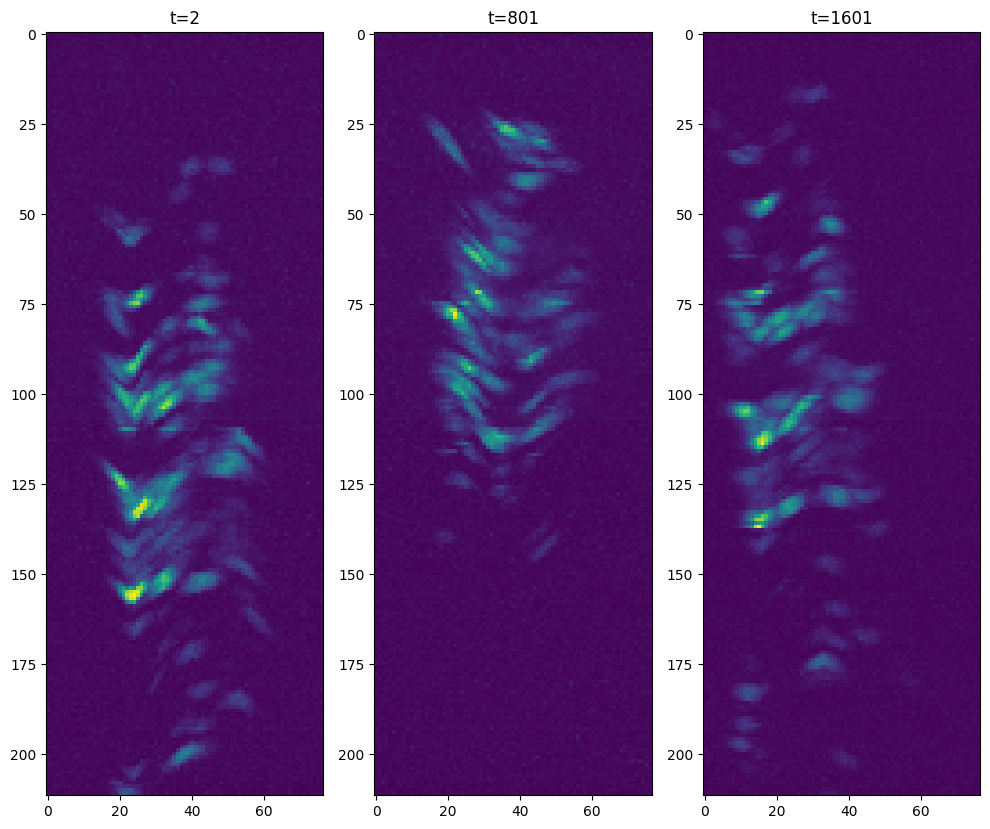

true

In [14]:
let
    dataset = "freely_moving"
    ch_view = 2 # 1 is blue or green, 2 is red
    figure(figsize=(10,10))
    dim = 1
    stack = nd2preview(param_paths[dataset]["path_nd2"], return_data=true, z_crop=params[dataset]["z_range"], ch=ch_view, n_z=params[dataset]["n_z"], dim=dim);
end

### Saving to NRRD

Expected runtime: 1 hour.

For more information, please refer to https://github.com/flavell-lab/ND2Process.jl

This section crops out piezo motion artifacts and saves each time point in the ND2 confocal recording as an NRRD file. If this section crashes, it may mean that you need to update the parameter `param["n_z"]`, or that your confocal recording terminated prematurely.

In [15]:
for dataset in keys(datasets)
    param_path = param_paths[dataset]
    param = params[dataset]
    nd2_to_nrrd(param_path["path_nd2"], param_path["path_root_process"], param["spacing_lat"], param["spacing_axi"], true,
        x_crop=param["x_range"], y_crop=param["y_range"], z_crop=param["z_range"], θ=param["θ"], chs=param["list_ch"], n_z=param["n_z"],
        NRRD_dir_name=param_path["path_dir_nrrd"], MIP_dir_name=param_path["path_dir_MIP"])
end

Progress: 100%|█████████████████████████████████████████| Time: 1:25:16
Progress: 100%|█████████████████████████████████████████| Time: 0:02:54
Progress: 100%|█████████████████████████████████████████| Time: 0:03:00
Progress: 100%|█████████████████████████████████████████| Time: 0:02:54
Progress: 100%|█████████████████████████████████████████| Time: 0:03:00


You can view the raw data by uncommenting this code:

In [16]:
let
    dataset = "freely_moving"
    t = 250
    ch = 2 # 1 is blue or green, 2 is red
    img = read_img(NRRD(joinpath(param_paths[dataset]["path_dir_nrrd"], param_paths[dataset]["get_basename"](t,ch)*".nrrd")));
    view_roi_3D(img, nothing, nothing, raw_contrast=2)
end

Node{WebIO.DOM}(WebIO.DOM(:html, :div), Any[Node{WebIO.DOM}(WebIO.DOM(:html, :div), Any[Scope(Node{WebIO.DOM}(WebIO.DOM(:html, :div), Any[Node{WebIO.DOM}(WebIO.DOM(:html, :div), Any[Node{WebIO.DOM}(WebIO.DOM(:html, :label), Any["z"], Dict{Symbol, Any}(:className => "interact ", :style => Dict{Any, Any}(:padding => "5px 10px 0px 10px")))], Dict{Symbol, Any}(:className => "interact-flex-row-left")), Node{WebIO.DOM}(WebIO.DOM(:html, :div), Any[Node{WebIO.DOM}(WebIO.DOM(:html, :input), Any[], Dict{Symbol, Any}(:max => 77, :min => 1, :attributes => Dict{Any, Any}(:type => "range", Symbol("data-bind") => "numericValue: index, valueUpdate: 'input', event: {change: function (){this.changes(this.changes()+1)}}", "orient" => "horizontal"), :step => 1, :className => "slider slider is-fullwidth", :style => Dict{Any, Any}()))], Dict{Symbol, Any}(:className => "interact-flex-row-center")), Node{WebIO.DOM}(WebIO.DOM(:html, :div), Any[Node{WebIO.DOM}(WebIO.DOM(:html, :p), Any[], Dict{Symbol, Any}(:attributes => Dict("data-bind" => "text: formatted_val")))], Dict{Symbol, Any}(:className => "interact-flex-row-right"))], Dict{Symbol, Any}(:className => "interact-flex-row interact-widget")), Dict{String, Tuple{AbstractObservable, Union{Nothing, Bool}}}("changes" => (Observable(0), nothing), "index" => (Observable(39), nothing)), Set{String}(), nothing, Asset[Asset("js", "knockout", "/home/candy/.julia/packages/Knockout/HReiN/src/../assets/knockout.js"), Asset("js", "knockout_punches", "/home/candy/.julia/packages/Knockout/HReiN/src/../assets/knockout_punches.js"), Asset("js", nothing, "/home/candy/.julia/packages/InteractBase/LJXv3/src/../assets/all.js"), Asset("css", nothing, "/home/candy/.julia/packages/InteractBase/LJXv3/src/../assets/style.css"), Asset("css", nothing, "/home/candy/.julia/packages/Interact/PENUy/src/../assets/bulma_confined.min.css")], Dict{Any, Any}("changes" => Any[WebIO.JSString("(function (val){return (val!=this.model[\"changes\"]()) ? (this.valueFromJulia[\"changes\"]=true, this.model[\"changes\"](val)) : undefined})")], "index" => Any[WebIO.JSString("(function (val){return (val!=this.model[\"index\"]()) ? (this.valueFromJulia[\"index\"]=true, this.model[\"index\"](val)) : undefined})")]), WebIO.ConnectionPool(Channel{Any}(32), Set{AbstractConnection}(), Base.GenericCondition{ReentrantLock}(Base.IntrusiveLinkedList{Task}(Task (runnable) @0x00007f2fe2c907e0, Task (runnable) @0x00007f2fe2c907e0), ReentrantLock(nothing, 0x00000000, 0x00, Base.GenericCondition{Base.Threads.SpinLock}(Base.IntrusiveLinkedList{Task}(nothing, nothing), Base.Threads.SpinLock(0)), (0, 0, 0)))), WebIO.JSString[WebIO.JSString("function () {\n    var handler = (function (ko, koPunches) {\n    ko.punches.enableAll();\n    ko.bindingHandlers.numericValue = {\n        init: function(element, valueAccessor, allBindings, data, context) {\n            var stringified = ko.observable(ko.unwrap(valueAccessor()));\n            stringified.subscribe(function(value) {\n                var val = parseFloat(value);\n                if (!isNaN(val)) {\n                    valueAccessor()(val);\n                }\n            });\n            valueAccessor().subscribe(function(value) {\n                var str = JSON.stringify(value);\n                if ((str == \"0\") && ([\"-0\", \"-0.\"].indexOf(stringified()) >= 0))\n                     return;\n                 if ([\"null\", \"\"].indexOf(str) >= 0)\n                     return;\n                stringified(str);\n            });\n            ko.applyBindingsToNode(\n                element,\n                {\n                    value: stringified,\n                    valueUpdate: allBindings.get('valueUpdate'),\n                },\n                context,\n            );\n        }\n    };\n    var json_data = {\"formatted_vals\":[\"1\",\"2\",\"3\",\"4\",\"5\",\"6\",\"7\",\"8\",\"9\",\"10\",\"11\",\"12\",\"13\",\"14\",\"15\",\"16\",\"17\",\"18\",\"19\",\"20\",\"21\",\"22\",\"23\",\"24\",\"25\",\"26\",\"

### Shear Correction

Expected runtime: 1 hour. GPU-accelerated.

The worm motion introduces shear into the frames, which needs to be corrected for subsequent steps of the pipeline to work well. Only the freely-moving dataset requires shear correction.

For more information, please see https://github.com/flavell-lab/FFTRegGPU.jl

In [17]:
getpid()

3780301

In [18]:
new_process = addprocs(1)[1]

2

In [19]:
@everywhere workers() begin
    using ImageDataIO
end

      From worker 2:	┌ Warning: You are using a non-official build of Julia. This may cause issues with CUDA.jl.
      From worker 2:	│ Please consider using an official build from https://julialang.org/downloads/.
      From worker 2:	└ @ CUDA ~/.julia/packages/CUDA/75aiI/src/initialization.jl:180


In [20]:
@eval @everywhere param_paths=$param_paths
@eval @everywhere params=$params

In [21]:
for dataset in datasets_freely_moving
    result = @spawnat new_process begin
        shear_params = Dict()
        shear_correction_nrrd!(param_paths[dataset], params[dataset], params[dataset]["ch_marker"], shear_params);
        shear_params
    end
    data_dicts[dataset]["shear_params"] = fetch(result)    
end

In [22]:
rmprocs(new_process)

Task (done) @0x00007f2fe0918fb0

You can view the shear-corrected data by running this code. The shear-correction operates in the `z`-dimension, so it's recommended to set `axis` to 1 or 2 to be able to view the neurons in the `z`-axis.

In [24]:
let
    t = 250
    ch = params["freely_moving"]["ch_marker"]
    img = read_img(NRRD(joinpath(param_paths["freely_moving"]["path_dir_nrrd_shearcorrect"], param_paths["freely_moving"]["get_basename"](t,ch)*".nrrd")));
    view_roi_3D(img, nothing, nothing, raw_contrast=2, axis=3)
end

Node{WebIO.DOM}(WebIO.DOM(:html, :div), Any[Node{WebIO.DOM}(WebIO.DOM(:html, :div), Any[Scope(Node{WebIO.DOM}(WebIO.DOM(:html, :div), Any[Node{WebIO.DOM}(WebIO.DOM(:html, :div), Any[Node{WebIO.DOM}(WebIO.DOM(:html, :label), Any["z"], Dict{Symbol, Any}(:className => "interact ", :style => Dict{Any, Any}(:padding => "5px 10px 0px 10px")))], Dict{Symbol, Any}(:className => "interact-flex-row-left")), Node{WebIO.DOM}(WebIO.DOM(:html, :div), Any[Node{WebIO.DOM}(WebIO.DOM(:html, :input), Any[], Dict{Symbol, Any}(:max => 77, :min => 1, :attributes => Dict{Any, Any}(:type => "range", Symbol("data-bind") => "numericValue: index, valueUpdate: 'input', event: {change: function (){this.changes(this.changes()+1)}}", "orient" => "horizontal"), :step => 1, :className => "slider slider is-fullwidth", :style => Dict{Any, Any}()))], Dict{Symbol, Any}(:className => "interact-flex-row-center")), Node{WebIO.DOM}(WebIO.DOM(:html, :div), Any[Node{WebIO.DOM}(WebIO.DOM(:html, :p), Any[], Dict{Symbol, Any}(:attributes => Dict("data-bind" => "text: formatted_val")))], Dict{Symbol, Any}(:className => "interact-flex-row-right"))], Dict{Symbol, Any}(:className => "interact-flex-row interact-widget")), Dict{String, Tuple{AbstractObservable, Union{Nothing, Bool}}}("changes" => (Observable(0), nothing), "index" => (Observable(39), nothing)), Set{String}(), nothing, Asset[Asset("js", "knockout", "/home/candy/.julia/packages/Knockout/HReiN/src/../assets/knockout.js"), Asset("js", "knockout_punches", "/home/candy/.julia/packages/Knockout/HReiN/src/../assets/knockout_punches.js"), Asset("js", nothing, "/home/candy/.julia/packages/InteractBase/LJXv3/src/../assets/all.js"), Asset("css", nothing, "/home/candy/.julia/packages/InteractBase/LJXv3/src/../assets/style.css"), Asset("css", nothing, "/home/candy/.julia/packages/Interact/PENUy/src/../assets/bulma_confined.min.css")], Dict{Any, Any}("changes" => Any[WebIO.JSString("(function (val){return (val!=this.model[\"changes\"]()) ? (this.valueFromJulia[\"changes\"]=true, this.model[\"changes\"](val)) : undefined})")], "index" => Any[WebIO.JSString("(function (val){return (val!=this.model[\"index\"]()) ? (this.valueFromJulia[\"index\"]=true, this.model[\"index\"](val)) : undefined})")]), WebIO.ConnectionPool(Channel{Any}(32), Set{AbstractConnection}(), Base.GenericCondition{ReentrantLock}(Base.IntrusiveLinkedList{Task}(Task (runnable) @0x00007f2fdcd481a0, Task (runnable) @0x00007f2fdcd481a0), ReentrantLock(nothing, 0x00000000, 0x00, Base.GenericCondition{Base.Threads.SpinLock}(Base.IntrusiveLinkedList{Task}(nothing, nothing), Base.Threads.SpinLock(0)), (10, -1, 139843556050208)))), WebIO.JSString[WebIO.JSString("function () {\n    var handler = (function (ko, koPunches) {\n    ko.punches.enableAll();\n    ko.bindingHandlers.numericValue = {\n        init: function(element, valueAccessor, allBindings, data, context) {\n            var stringified = ko.observable(ko.unwrap(valueAccessor()));\n            stringified.subscribe(function(value) {\n                var val = parseFloat(value);\n                if (!isNaN(val)) {\n                    valueAccessor()(val);\n                }\n            });\n            valueAccessor().subscribe(function(value) {\n                var str = JSON.stringify(value);\n                if ((str == \"0\") && ([\"-0\", \"-0.\"].indexOf(stringified()) >= 0))\n                     return;\n                 if ([\"null\", \"\"].indexOf(str) >= 0)\n                     return;\n                stringified(str);\n            });\n            ko.applyBindingsToNode(\n                element,\n                {\n                    value: stringified,\n                    valueUpdate: allBindings.get('valueUpdate'),\n                },\n                context,\n            );\n        }\n    };\n    var json_data = {\"formatted_vals\":[\"1\",\"2\",\"3\",\"4\",\"5\",\"6\",\"7\",\"8\",\"9\",\"10\",\"11\",\"12\",\"13\",\"14\",\"15\",\"16\",\"17\",\"18\",\"19\",\"20\",\"21\",\"22\",\"23\",\"24\",

In [25]:
log_prog("Shear Correction", param_paths["freely_moving"]["path_log_file"])

17

### Crop and rotate images

Expected runtime: 45 minutes. GPU-accelerated.

We next crop and rotate the images to avoid spending computation time dealing with empty pixels. Since we are dealing with freely moving animals, we cannot do this globally as allowed in `nd2_to_nrrd`, so we must instead do it on a frame-by-frame basis, modifying the cropping parameters each time to account for the worm's motion.

This code will usually give a warning about out-of-focus timepoints. If there are too many of them (eg: several hundred), your dataset likely had severe focus problems and it may give low quality data.

For more information, please refer to https://flavell-lab.github.io/SegmentationTools.jl/stable/crop

In [26]:
new_process = addprocs(1)[1]

3

In [27]:
@everywhere workers() begin
    using ImageDataIO
    using SegmentationTools
end

      From worker 3:	┌ Warning: You are using a non-official build of Julia. This may cause issues with CUDA.jl.
      From worker 3:	│ Please consider using an official build from https://julialang.org/downloads/.
      From worker 3:	└ @ CUDA ~/.julia/packages/CUDA/75aiI/src/initialization.jl:180


In [28]:
@eval @everywhere param_paths=$param_paths
@eval @everywhere params=$params

In [29]:
for dataset = keys(datasets)
    result = @spawnat new_process begin
        dict_param_crop_rot = Dict()
        nrrd_key = (dataset in datasets_freely_moving) ? "path_dir_nrrd_shearcorrect" : "path_dir_nrrd"
        dict_error_crop_rot, focus_issues = crop_rotate_dset!(param_paths[dataset], params[dataset], params[dataset]["t_range"], [params[dataset]["ch_marker"]], dict_param_crop_rot, save_MIP=true, nrrd_dir_key=nrrd_key)
        
        dict_error_crop_rot, focus_issues, dict_param_crop_rot
    end
    error_dicts[dataset]["dict_error_crop_rot"], data_dicts[dataset]["focus_issues"], data_dicts[dataset]["dict_param_crop_rot"] = fetch(result)
end;

      From worker 3:	sys:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.


In [30]:
rmprocs(new_process)

Task (done) @0x00007f2fe27d0e20

### Delete bad frames
Remove all time points where the worm was not visible or otherwise unusable. (Do not delete out of focus frames.)

In [31]:
for dataset = keys(datasets)
    param = params[dataset]
    param["t_range"] = [t for t in param["t_range"] if !(t in keys(error_dicts[dataset]["dict_error_crop_rot"])) || error_dicts[dataset]["dict_error_crop_rot"][t] == ErrorException("Worm out of focus")]
    data_dicts[dataset]["t_range"] = param["t_range"]
    JLD2.@save(param_paths[dataset]["path_param"], param)
end

In [32]:
for dataset = keys(datasets)
    data_dict = data_dicts[dataset]
    JLD2.@save(param_paths[dataset]["path_data_dict"], data_dict)
end

### Total-Variation Noise Filtering

Expected runtime: 10 minutes. GPU-accelerated.

This script filters the cropped data in the marker (red) channel to denoise it and make it easier for the registration to converge. The channel alignment registration does not use filtered data.

For more information, please refer to https://github.com/flavell-lab/GPUFilter.jl

In [33]:
new_process = addprocs(1)[1]

4

In [34]:
@everywhere workers() begin
    using ImageDataIO
end

      From worker 4:	┌ Warning: You are using a non-official build of Julia. This may cause issues with CUDA.jl.
      From worker 4:	│ Please consider using an official build from https://julialang.org/downloads/.
      From worker 4:	└ @ CUDA ~/.julia/packages/CUDA/75aiI/src/initialization.jl:180


In [35]:
@eval @everywhere param_paths=$param_paths
@eval @everywhere params=$params

In [36]:
for dataset = keys(datasets)
    result = @spawnat new_process begin
        filter_nrrd_gpu(param_paths[dataset], param_paths[dataset]["path_dir_nrrd_crop"], params[dataset]["t_range"], [params[dataset]["ch_marker"]], param_paths[dataset]["get_basename"])
    end
    fetch(result)
end

      From worker 4:	ch2 parameter:
      From worker 4:	mean(λ): 12.707198 std(λ): 0.7219687
      From worker 4:	ch2 parameter:
      From worker 4:	mean(λ): 26.719685 std(λ): 3.3754723
      From worker 4:	ch2 parameter:
      From worker 4:	mean(λ): 26.578608 std(λ): 1.5825218
      From worker 4:	ch2 parameter:
      From worker 4:	mean(λ): 19.396626 std(λ): 0.8231015
      From worker 4:	ch2 parameter:
      From worker 4:	mean(λ): 16.727413 std(λ): 0.1862612


In [37]:
rmprocs(new_process)

Task (done) @0x00007f2fe0601140

In [38]:
log_prog("Cropping", param_paths["freely_moving"]["path_log_file"])

9

### Finding head location

Expected runtime: 20 minutes. GPU-accelerated.

The first step in determining which timepoints to register to each other is finding the location of the worm's head in the frames, and frames where the head cannot be found from the analysis. This is done with a custom-trained 2D UNet.

For more information, please refer to https://flavell-lab.github.io/SegmentationTools.jl/stable/find_head

In [39]:
new_process = addprocs(1)[1]

5

In [40]:
@everywhere workers() begin
    using ImageDataIO
    using NRRDIO
    using SegmentationTools
    using UNet2D
end

      From worker 5:	┌ Warning: You are using a non-official build of Julia. This may cause issues with CUDA.jl.
      From worker 5:	│ Please consider using an official build from https://julialang.org/downloads/.
      From worker 5:	└ @ CUDA ~/.julia/packages/CUDA/75aiI/src/initialization.jl:180


In [41]:
@eval @everywhere param_paths=$param_paths
@eval @everywhere params=$params

In [42]:
for dataset = keys(datasets)
    data_dict = data_dicts[dataset]
    error_dict = error_dicts[dataset]
    
    @eval @everywhere dict_param_crop_rot=$(data_dict["dict_param_crop_rot"])

    result = @spawnat new_process begin
        param_path = param_paths[dataset]
        param = params[dataset]
    
        nrrd_dir = (dataset in datasets_freely_moving) ? "path_dir_nrrd_shearcorrect" : "path_dir_nrrd"
        img_size = size(read_img(NRRD(joinpath(param_path[nrrd_dir], param_path["get_basename"](1,2)*".nrrd"))))
        model = create_model(1,1,8,param_path["path_head_unet_model"]);
        head_pos, head_errs = find_head_unet(param_path, param, dict_param_crop_rot, model, img_size, nrrd_dir=nrrd_dir, use_cropnet=true);
        if !(dataset in datasets_freely_moving)
            head_pos_uncropped, head_errs_uncropped = find_head_unet(param_path, param, dict_param_crop_rot, model, img_size, nrrd_dir=nrrd_dir, crop=false, use_cropnet=true);
        else
            head_pos_uncropped = nothing
            head_errs_uncropped = nothing
        end
        head_pos, head_errs, head_pos_uncropped, head_errs_uncropped
    end
    data_dict["head_pos"], error_dict["head_errs"], data_dict["head_pos_uncropped"], error_dict["head_errs_uncropped"] = fetch(result)
end;

      From worker 5:	sys:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.


In [43]:
for dataset = datasets_freely_moving
    @eval @everywhere dict_param_crop_rot=$(data_dicts[dataset]["dict_param_crop_rot"])
    @eval @everywhere head_pos=$(data_dicts[dataset]["head_pos"])
    result = @spawnat new_process begin
        param_path = param_paths[dataset]
        param = deepcopy(params[dataset])
        param["t_range"] = [t for t in keys(dict_param_crop_rot) if "crop" in keys(dict_param_crop_rot[t]) && !(t in keys(head_pos))]
        nrrd_dir = "path_dir_nrrd"
        img_size = size(read_img(NRRD(joinpath(param_path[nrrd_dir], param_path["get_basename"](1,2)*".nrrd"))))
        model = create_model(1,1,8,param_path["path_head_unet_model"]);
        head_pos_new, head_errs_retry = find_head_unet(param_path, param, dict_param_crop_rot, model, img_size, nrrd_dir=nrrd_dir, use_cropnet=true);
        for t in keys(head_pos_new)
            head_pos[t] = head_pos_new[t]
        end
        head_pos, head_errs_retry
    end
    data_dicts[dataset]["head_pos"], error_dicts[dataset]["head_errs_retry"] = fetch(result)
end

In [44]:
rmprocs(new_process)

Task (done) @0x00007f30e1469460

This line of code tells you the fraction of times that the head-detection UNet was successful at determining the worm's head location. If this number is below 90%, it usually means that your dataset is very low quality. If you made a new strain and are consistently getting a value below 90%, you may need to retrain the 2D UNet on that strain. Additionally, you may want to use ImageClick to manually label head positions for this dataset.

In [45]:
length(data_dicts["freely_moving"]["head_pos"]) / params["freely_moving"]["max_t"]

0.929375

### Manually adjusting head position

This line of code lets you manually examine the head UNet output at individual timepoints in individual datasets. If you need to manually fix errors, you can comment out line 15 (`hp = data_dicts[dataset]["head_pos"][t]`) and uncomment line 16 (`hp = [x,y]`), replacing `x` and `y` with your manual estimates of the head position.

Time point displayed: 391
Image size: (284, 120)
Detected head position: [51, 53]


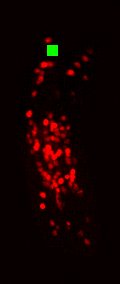

In [46]:
let
    dataset = "freely_moving"#"all_red"
    t = 391#reg_timepts[dataset] # you may want to set this to reg_timepts[dataset] for immobilized datasets
    if !(t in keys(data_dicts[dataset]["head_pos"]))
        println(error_dicts[dataset]["head_errs_retry"][t])
    else
        println("Time point displayed: $t")
        contrast = 1
        
        path_nrrd = joinpath(param_paths[dataset]["path_dir_nrrd_crop"], param_paths[dataset]["get_basename"](t,2) * ".nrrd")
        img = maxprj(read_img(NRRD(path_nrrd)), dims=3)#[1:322,1:210]
        
        img_max = percentile(reshape(img, (prod(size(img)),)), 100-contrast)
        img_min = percentile(reshape(img, (prod(size(img)),)), contrast)
        
        img_hp = zeros(size(img))
        println("Image size: $(size(img))")
        hp = data_dicts[dataset]["head_pos"][t]
#         hp = [x,y]
        println("Detected head position: $(hp)")
        img_hp[hp[1]-5:hp[1]+5,
                hp[2]-5:hp[2]+5] .= 1
        
        RGB.(max.(0,min.(1,(img .- img_min) ./ (img_max - img_min))), img_hp, 0)
    end
end

If you need to manually adjust any incorrect or missing head positions, you can do so here by uncommenting this code and replacing `dataset`, `t`, `x`, and `y` with the appropriate values:

In [47]:
# data_dicts[dataset]["head_pos"][t] = [x,y]

### Saving head position

In [48]:
for dataset = datasets_freely_moving
    param = params[dataset]
    param["t_range"] = [t for t in param["t_range"] if (t in keys(data_dicts[dataset]["head_pos"]))]
    data_dicts[dataset]["t_range"] = param["t_range"]
    JLD2.@save(param_paths[dataset]["path_param"], param)
end

The following code will display a warning message if the head detector failed on any timepoints in any datasets that are being registered back to the freely-moving dataset. If this happens, it is recommended to run the code in "Manually adjusting head position" for `reg_timepts[dataset]"` and ensure that the value is correct, or modify it if it is not.

In [49]:
for dataset = keys(datasets)
    f = open(param_paths[dataset]["path_head_pos"],"w")
    for t in params[dataset]["t_range"]
        if !(t in keys(data_dicts[dataset]["head_pos"]))
            if dataset in datasets_register
                @warn("$(dataset) timepoint $(t) head location not found.")
            end
            continue
        end
        hp = data_dicts[dataset]["head_pos"][t]
        write(f, "$(t)    $(hp[1]) $(hp[2])\n")
    end
    close(f)
end;

In [50]:
for dataset = keys(datasets)
    data_dict = data_dicts[dataset]
    JLD2.@save(param_paths[dataset]["path_data_dict"], data_dict)
end

In [51]:
log_prog("Head Location", param_paths["freely_moving"]["path_log_file"])

14

# Registration

### Registration Graph

Expected runtime: 5 minutes.

This script determines which frames are similar to each other and generates a list of pairs of time points to register to each other. For more information, see https://flavell-lab.github.io/WormFeatureDetector.jl, https://github.com/flavell-lab/WormCurveFinder.jl, and https://flavell-lab.github.io/RegistrationGraph.jl.

Extremely rarely, the head detector will produce a head position even when the worm is not in the field of view (typically, due to a tracking glitch). If this happens, the following code blocks may crash, and any subsequent registration code will fail. If this happens, the solution is to find which timepoints in `param["t_range"]` are causing the crash and remove them. Typically the easiest way to do this is to look at either `data_dict["curves"]` or `data_dicts["$(dataset)_to_central"]["curves"]` and finding when the last successful timepoint was. If necessary, you can also binary search over the full set of timepoints until the problematic ones are identified.

Define registration graph for immobilized datasets:

In [52]:
for dataset = keys(datasets)
    data_dicts[dataset]["registration_problems"] = []
    if dataset in datasets_freely_moving
        continue
    end
    for t=1:params[dataset]["max_t"]
        if t!=params[dataset]["reg_timept"]
            push!(data_dicts[dataset]["registration_problems"], (t,params[dataset]["reg_timept"]))
        end
    end
end

Define registration graph for immobilized to freely-moving registration:

In [53]:
for dataset in datasets_register
    data_dicts["$(dataset)_to_central"] = Dict()
    data_dicts["$(dataset)_to_central"]["max_t"] = params["freely_moving"]["max_t"]+params[dataset]["max_t"]
    data_dicts["$(dataset)_to_central"]["curves"] = Vector{Tuple{Vector{Float64}, Vector{Float64}}}(undef, data_dicts["$(dataset)_to_central"]["max_t"])
    heur! = (t1, t2) -> elastix_difficulty_wormcurve!(data_dicts["$(dataset)_to_central"]["curves"], params["freely_moving"], param_paths["freely_moving"], param_paths[dataset], t1, t2, params["freely_moving"]["ch_marker"], save_curve_fig=false, max_fixed_t=params["freely_moving"]["max_t"]);
    data_dicts["$(dataset)_to_central"]["t_range"] = collect(deepcopy(params["freely_moving"]["t_range"]))
    append!(data_dicts["$(dataset)_to_central"]["t_range"], params[dataset]["t_range"].+params["freely_moving"]["max_t"])
    data_dicts["$(dataset)_to_central"]["elastix_difficulty"] = generate_elastix_difficulty(param_paths["freely_moving"]["path_elastix_difficulty_$(dataset)"], data_dicts["$(dataset)_to_central"]["t_range"], heur!);
end

Progress: 100%|█████████████████████████████████████████| Time: 0:01:12


In [54]:
for dataset in datasets_register
    if dataset in datasets_freely_moving
        error("Registering freely-moving datasets together not yet supported in this version of ANTSUN. Please see old ANTSUN_merge.ipynb script.")
    else
        data_dicts["$(dataset)_to_central"]["registration_problems"] = []
        best_timepts = sort(1:length(params[dataset_central]["t_range"]), by=i->data_dicts["$(dataset)_to_central"]["elastix_difficulty"][1:end-length(params[dataset]["t_range"]), length(params[dataset_central]["t_range"])+params[dataset]["reg_timept"]][i])
        for i=1:n_timepts_merge[dataset]
            push!(data_dicts["$(dataset)_to_central"]["registration_problems"], (params[dataset]["reg_timept"], params[dataset_central]["t_range"][best_timepts[i]]))
        end
    end
end

Define registration graph for freely-moving dataset:

In [55]:
for dataset in datasets_freely_moving
    data_dict = data_dicts[dataset]
    param = params[dataset]
    param_path = param_paths[dataset]
    data_dict["curves"] = Vector{Tuple{Vector{Float64}, Vector{Float64}}}(undef, param["max_t"])
    heur! = (t1, t2) -> elastix_difficulty_wormcurve!(data_dict["curves"], param, param_path, param_path, t1, t2, param["ch_marker"], save_curve_fig=true);
    data_dict["elastix_difficulty"] = fill(Inf, (param["max_t"], param["max_t"]))
    data_dict["elastix_difficulty"][param["t_range"], param["t_range"]] .= generate_elastix_difficulty(param_path["path_elastix_difficulty"], param["t_range"], heur!);
end;

Progress: 100%|█████████████████████████████████████████| Time: 0:02:563:45


If the following code displays any `Disconnected graph` warnings, they are usually safe to ignore if they are due to `Disconnected for merge`, but if you see any output of the form `Disconnected for i=`, that represents a serious problem and may require manually adjusting the registration graph to ensure it is connected. It is very likely that you will get such a message if you try running `ANTSUN` on fully-immobilized animals; in this case it is recommended to bypass the registration graph computation entirely and manually specify the graph.

In [56]:
## THIS CODE WON'T WORK WITH >2 MERGES

for dataset in datasets_freely_moving
    param = params[dataset]
    param_path = param_paths[dataset]
    data_dict = data_dicts[dataset]
    error_dict = error_dicts[dataset]
    for i=1:(param["max_graph_num"] < param["max_t"] ? 2 : 1)
        path_diff_i = replace(param_path["path_elastix_difficulty"], ".txt"=>"_$(i).txt")
        if i == 1
            t_inc = [t for t in param["t_range"] if t <= param["max_graph_num"]]
        else
            t_inc = [t for t in param["t_range"] if t > param["max_graph_num"]]
        end

        open(path_diff_i, "w") do f
            write(f, string(t_inc)*"\n")
            write(f, replace(string(data_dict["elastix_difficulty"][t_inc, t_inc]), ";"=>"\n"))
        end

        graph = load_graph(path_diff_i, func=identity);
        subgraph, unconnected = make_voting_subgraph(graph, param["degree"])
        
        if length(unconnected) > 0
            @warn("Disconnected for i=$i: $unconnected")
        end
        output_graph(subgraph, replace(param_path["path_reg_prob"], ".txt"=>"_$(i).txt"))

        if i > 1
            path_diff_merge = replace(param_path["path_elastix_difficulty"], ".txt"=>"_merge$(i).txt")
            open(path_diff_merge, "w") do f
                t_merge = param["t_range"]
                write(f, string(t_merge)*"\n")

                diff_merge = deepcopy(data_dict["elastix_difficulty"])
                diff_merge[t_inc, t_inc] .= Inf

                t_inc_1 = [t for t in param["t_range"] if t <= param["max_graph_num"]]
                diff_merge[t_inc_1, t_inc_1] .= Inf

                write(f, replace(string(diff_merge[t_merge, t_merge]), ";"=>"\n"))
            end
            graph = load_graph(path_diff_merge, func=identity);
            subgraph, unconnected = make_voting_subgraph(graph, param["degree_dataset"])
            if length(unconnected) > 0
                println("Disconnected for merge: $unconnected. This should be OK to ignore.")
            end
            output_graph(subgraph, replace(param_path["path_reg_prob"], ".txt"=>"_merge$(i).txt"))
        end
    end
    # loads registration problems you previously computed from the graph
    if param["max_graph_num"] < param["max_t"]
        data_dict["registration_problems"] = load_registration_problems([replace(param_path["path_reg_prob"], ".txt"=>"_1.txt"), replace(param_path["path_reg_prob"], ".txt"=>"_2.txt"), replace(param_path["path_reg_prob"], ".txt"=>"_merge2.txt")]);
    else
        data_dict["registration_problems"] = load_registration_problems([replace(param_path["path_reg_prob"], ".txt"=>"_1.txt")]);
    end;
end

In [57]:
for dataset = datasets_register
    open(param_paths[dataset_central]["path_reg_prob_$dataset"], "w") do f
        for problem in data_dicts["$(dataset)_to_central"]["registration_problems"]
            write(f, "$(problem[1]) $(problem[2])\n")
        end
    end
end
for dataset = keys(datasets)
    open(param_paths[dataset]["path_reg_prob"], "w") do f
        for problem in data_dicts[dataset]["registration_problems"]
            write(f, "$(problem[1]) $(problem[2])\n")
        end
    end
end

In [58]:
for dataset = keys(datasets)
    data_dict = data_dicts[dataset]
    JLD2.@save(param_paths[dataset]["path_data_dict"], data_dict)
end

for dataset = datasets_register
    data_dict = data_dicts["$(dataset)_to_central"]
    JLD2.@save(joinpath(param_paths[dataset_central]["path_root_process"], "$(dataset)_registered_data_dict.jld2"), data_dict)
end

In [59]:
GC.gc()

In [60]:
log_prog("Registration Graph", param_paths["freely_moving"]["path_log_file"])

19

In [13]:
### I manually loaded in the registration problems from sreeparna's original data_dict
### load original data_dicts
orig_data_dicts = Dict()

for dataset in keys(datasets)
    if dataset in datasets_freely_moving
        # path_root_process = path_root_process_freelymoving
        path_root_process = "/data1/shared/panneuralGFP/data_processed/2024-07-17-01_output"
    else
        path_root_process = joinpath("/data1/shared/panneuralGFP/data_processed/2024-07-17-01_output/neuropal", datasets[dataset])
    end
    
    path_ = joinpath(path_root_process, "orig_data_dict.jld2")
    if isfile(path_)
        f = JLD2.jldopen(path_)
        orig_data_dicts[dataset] = f["data_dict"]
        close(f)
    else
        orig_data_dicts[dataset] = Dict()
    end           
end

for dataset in datasets_register
    path_root_process = "/data1/shared/panneuralGFP/data_processed/2024-07-17-01_output"
    path_ = joinpath(path_root_process, "orig_$(dataset)_registered_data_dict.jld2")
    if isfile(path_)
        f = JLD2.jldopen(path_)
        orig_data_dicts["$(dataset)_to_central"] = f["data_dict"]
        close(f)
    else
        orig_data_dicts["$(dataset)_to_central"] = Dict()
    end
end

In [14]:
# use old registration problems from sreeparna
for dataset in keys(datasets)
    data_dicts[dataset]["registration_problems"] = copy(orig_data_dicts[dataset]["registration_problems"])
end

for dataset in datasets_register
    data_dicts["$(dataset)_to_central"]["registration_problems"] = copy(orig_data_dicts[dataset]["registration_problems"])
end

In [15]:
for dataset = keys(datasets)
    data_dict = data_dicts[dataset]
    JLD2.@save(param_paths[dataset]["path_data_dict"], data_dict)
end

for dataset = datasets_register
    data_dict = data_dicts["$(dataset)_to_central"]
    JLD2.@save(joinpath(param_paths[dataset_central]["path_root_process"], "$(dataset)_registered_data_dict.jld2"), data_dict)
end

In [13]:
data_dicts[dataset_central]["registration_problems"]

12444-element Vector{Any}:
 (1, 18)
 (1, 30)
 (1, 73)
 (1, 152)
 (1, 174)
 (1, 217)
 (1, 254)
 (1, 271)
 (1, 277)
 (1, 287)
 (1, 478)
 (1, 540)
 (1, 543)
 ⋮
 (797, 818)
 (797, 1145)
 (797, 1147)
 (797, 1259)
 (798, 1215)
 (798, 1238)
 (799, 1183)
 (799, 1238)
 (799, 1250)
 (799, 1513)
 (800, 1034)
 (800, 1071)

## Registration on the OpenMind cluster

After the registration problems have been determined, the data can be uploaded to OpenMind. This code generates a number of registration scripts to run all of the immobilized to freely-moving, intra-dataset immobilized, and camera alignment registration problems using `elastix`, and then executes them all with `sbatch`. If you encounter errors here, it is likely that you have misconfigured something related to interfacing with OpenMind, either in a parameter setting in this notebook or on your computer (eg: `ssh` keys).

### Immobilized and camera alignment registration

Expected runtime: 1-8 hours.

#### Set up all intra-filter immobilized registrations in the red channel

In [14]:
# syncs data to server and generates sbatch files for elastix
for dataset = keys(datasets)
    if dataset in datasets_freely_moving
        continue
    else
        @time write_sbatch_graph(data_dicts[dataset]["registration_problems"], param_paths[dataset], param_paths[dataset], params[dataset],
            nrrd_dir_key="path_dir_nrrd", nrrd_om_dir_key="path_om_nrrd")
    end
end

Resetting /data1/shared/panneuralGFP/data_processed_220/2024-07-17-01_output/neuropal/2024-07-17-05/elx_commands...
Writing elastix script files...
Syncing data to server...
 25.679574 seconds (1.58 M allocations: 106.650 MiB, 0.17% gc time)
Resetting /data1/shared/panneuralGFP/data_processed_220/2024-07-17-01_output/neuropal/2024-07-17-04/elx_commands...
Writing elastix script files...
Syncing data to server...
 23.156274 seconds (8.70 k allocations: 838.711 KiB)
Resetting /data1/shared/panneuralGFP/data_processed_220/2024-07-17-01_output/neuropal/2024-07-17-03/elx_commands...
Writing elastix script files...
Syncing data to server...
 23.526489 seconds (8.71 k allocations: 838.977 KiB)
Resetting /data1/shared/panneuralGFP/data_processed_220/2024-07-17-01_output/neuropal/2024-07-17-02/elx_commands...
Writing elastix script files...
Syncing data to server...
 22.792797 seconds (8.69 k allocations: 838.242 KiB)


#### Set up camera alignment registration

In [15]:
@time write_sbatch_graph([(x,x) for x in params[dataset_central]["t_range"]], param_paths[dataset_central], 
    param_paths[dataset_central], params[dataset_central], moving_channel_key="ch_activity",
    reg_dir_key="path_dir_reg_activity_marker", reg_om_dir_key="path_om_reg_activity_marker",
    nrrd_dir_key="path_dir_nrrd", nrrd_om_dir_key="path_om_nrrd",
    path_head_rotate_key="path_head_rotate_activity_marker", parameter_files_key="parameter_files_activity_marker",
    job_name_key="job_name_activity_marker", cmd_dir_key="path_dir_cmd_am", cmd_om_key="path_om_cmd_am", clear_cmd_dir=true);


Resetting /data1/shared/panneuralGFP/data_processed_220/2024-07-17-01_output/elx_commands_ch1to2...
Writing elastix script files...
Syncing data to server...
411.210662 seconds (741.80 k allocations: 73.213 MiB, 0.04% gc time)


#### Set up intra-filter immobilized registrations in the green channel

In [16]:
for dataset = keys(datasets)
    if dataset in datasets_freely_moving
        continue
    end
    @time write_sbatch_graph(data_dicts[dataset]["registration_problems"], param_paths[dataset], param_paths[dataset], params[dataset],
        moving_channel_key="ch_activity", fixed_channel_key="ch_activity", reg_dir_key="path_dir_reg_activity",
        reg_om_dir_key="path_om_reg_activity", job_name_key="job_name_activity", cmd_dir_key="path_dir_cmd_activity", 
        cmd_om_key="path_om_cmd_activity", clear_cmd_dir=false, nrrd_dir_key="path_dir_nrrd", nrrd_om_dir_key="path_om_nrrd")
end


Writing elastix script files...
Syncing data to server...
 20.594100 seconds (13.72 k allocations: 1.206 MiB)
Writing elastix script files...
Syncing data to server...
 20.308533 seconds (8.18 k allocations: 797.547 KiB)
Writing elastix script files...
Syncing data to server...
 20.543782 seconds (8.20 k allocations: 798.203 KiB)
Writing elastix script files...
Syncing data to server...
 20.729687 seconds (8.20 k allocations: 797.859 KiB)


In [17]:
paths_cmd = []
for dataset in keys(datasets)
    if !(dataset == dataset_central)
        push!(paths_cmd, param_paths[dataset]["path_om_cmd_array"])
    end
end

The following lines of code submit the jobs for running on OpenMind. Note that if the code is stalling for a long time without running, you may have a file that got stuck in your `lock` directory (this most commonly happens if a copy of `ANTSUN` fails to communicate with OpenMind to query whether its jobs are completed). Make sure that there is no other copy of `ANTSUN` that is currently running jobs on OpenMind, and then clear your `lock` directory to get the code to run.

In [18]:
@time run_elastix_openmind(param_paths[dataset_central], params[dataset_central], extra_cmd_paths=paths_cmd)

This system is only available via MIT network or via the MIT VPN
This system is only available via MIT network or via the MIT VPN
This system is only available via MIT network or via the MIT VPN
This system is only available via MIT network or via the MIT VPN
This system is only available via MIT network or via the MIT VPN
This system is only available via MIT network or via the MIT VPN
This system is only available via MIT network or via the MIT VPN
This system is only available via MIT network or via the MIT VPN


 32.998969 seconds (1.03 M allocations: 70.351 MiB, 0.84% gc time)


39454190

In [19]:
log_prog("OM Registration (jobs submitted)", param_paths["freely_moving"]["path_log_file"])

33

# Freely-moving registration

Expected runtime: 8 hours.

### Euler registration

Next, the images need to be transformed via rigid-body registration to initialize them for registration network processing.

Uses GPU. Expected runtime: 6 hours.

In [69]:
new_process = addprocs(1)[1]

6

In [70]:
@everywhere workers() begin
    using ImageDataIO
    using PyCall
    using NRRDIO
    using Statistics
    using ImageRegistration
    using FlavellBase
    using ProgressMeter
    using MultivariateStats
end

      From worker 6:	┌ Warning: You are using a non-official build of Julia. This may cause issues with CUDA.jl.
      From worker 6:	│ Please consider using an official build from https://julialang.org/downloads/.
      From worker 6:	└ @ CUDA ~/.julia/packages/CUDA/75aiI/src/initialization.jl:180
      From worker 6:	2024-11-21 15:18:45.779437: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
      From worker 6:	2024-11-21 15:18:45.779480: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
      From worker 6:	2024-11-21 15:18:45.787122: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [71]:
@eval @everywhere param_paths=$param_paths
@eval @everywhere datasets=$datasets
@eval @everywhere registration_problems=$(Dict(dataset => data_dicts[dataset]["registration_problems"] for dataset in datasets_freely_moving))
@eval @everywhere params=$params
@eval @everywhere datasets_freely_moving=$datasets_freely_moving

In [72]:
result = @spawnat new_process begin
    memory_dict = Dict()
    euler_parameters = Dict()
    
    for dataset in datasets_freely_moving
        for (moving, fixed) in registration_problems[dataset]
            fixed_image = read_img(NRRD(joinpath(param_paths[dataset]["path_dir_nrrd_filt_recropped"], param_paths[dataset]["get_basename"](fixed,2)*".nrrd")))
            moving_image_nrrd = NRRD(joinpath(param_paths[dataset]["path_dir_nrrd_filt_recropped"], param_paths[dataset]["get_basename"](moving,2)*".nrrd"))
            moving_image = read_img(moving_image_nrrd)
    
            euler_parameters[(moving, fixed)], euler_transformed_moving_image = euler_register!(param_paths[dataset], params[dataset], fixed_image, moving_image, memory_dict)
    
            save_dir = joinpath(param_paths[dataset]["path_dir_reg"], "$(moving)to$(fixed)")
            create_dir(save_dir)
            write_nrrd(joinpath(save_dir, "euler_transformed.nrrd"), Float32.(euler_transformed_moving_image), spacing(moving_image_nrrd))
        end
    end
    euler_parameters
end

Future(6, 1, 80, ReentrantLock(nothing, 0x00000000, 0x00, Base.GenericCondition{Base.Threads.SpinLock}(Base.IntrusiveLinkedList{Task}(nothing, nothing), Base.Threads.SpinLock(0)), (0, 139771048011808, 139744990575056)), nothing)

In [73]:
data_dicts[dataset_central]["euler_parameters"] = fetch(result);

In [74]:
rmprocs(new_process)

Task (done) @0x00007f18ea81a8b0

In [75]:
for dataset = keys(datasets)
    data_dict = data_dicts[dataset]
    data_dict["t_range"] = params[dataset]["t_range"]
    JLD2.@save(param_paths[dataset]["path_data_dict"], data_dict)
end

for dataset = datasets_register
    data_dict = data_dicts["$(dataset)_to_central"]
    JLD2.@save(joinpath(param_paths[dataset_central]["path_root_process"], "$(dataset)_registered_data_dict.jld2"), data_dict)
end

In [76]:
log_prog("Euler Registration", param_paths["freely_moving"]["path_log_file"])

19

### Neural network registration with BrainAlignNet

The aligned images are next put into the registration network to compute DDFs for each registration problem.

Uses GPU. Expected runtime: 5 hours.

In [77]:
new_process = addprocs(1)[1]

7

In [78]:
@everywhere workers() begin
    # ENV["TF_GPU_ALLOCATOR"] = "cuda_malloc_async"
    using ImageDataIO
    using PyCall
    using NRRDIO
    using Statistics
    using ImageRegistration
    using FlavellBase
    using ProgressMeter
    using MultivariateStats
    using HDF5
end

      From worker 7:	┌ Warning: You are using a non-official build of Julia. This may cause issues with CUDA.jl.
      From worker 7:	│ Please consider using an official build from https://julialang.org/downloads/.
      From worker 7:	└ @ CUDA ~/.julia/packages/CUDA/75aiI/src/initialization.jl:180
      From worker 7:	2024-11-21 21:21:48.498638: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
      From worker 7:	2024-11-21 21:21:48.498672: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
      From worker 7:	2024-11-21 21:21:48.500245: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [79]:
@eval @everywhere param_paths=$param_paths
@eval @everywhere datasets=$datasets
@eval @everywhere registration_problems=$(Dict(dataset => data_dicts[dataset]["registration_problems"] for dataset in datasets_freely_moving))
@eval @everywhere params=$params
@eval @everywhere datasets_freely_moving=$datasets_freely_moving

In [80]:
param_paths["freely_moving"]["path_dir_reg"]

"/data1/shared/panneuralGFP/data_processed_220/2024-07-17-01_output/Registered"

In some cases, if the registration failed or you want to update to a newer version of the network, you may want to delete all of your old registrations. To do so, uncomment the following blocks of code:

In [ ]:
### see what's in the folder before proceeding
# for dataset in datasets_freely_moving
#     @showprogress for problem in data_dicts[dataset]["registration_problems"]
#         path_tfm_img = joinpath(param_paths[dataset]["path_dir_reg"], "$(problem[1])to$(problem[2])", "predicted_fixed_image.nrrd")
#         if isfile(path_tfm_img)
#             rm(path_tfm_img)
#         end
#         path_ddf = joinpath(param_paths[dataset]["path_dir_reg"], "$(problem[1])to$(problem[2])", "ddf.h5")
#         if isfile(path_ddf)
#             rm(path_ddf)
#         end
#     end
# end

In [81]:
result = @spawnat new_process begin
    predict = pyimport("deepreg.predict")
    overwrite_existing = true # set this to `true` to overwrite existing registrations; otherwise the code will skip over them and focus on incomplete registrations
    model = nothing
    nrrd_spacing = nothing
    for dataset in datasets_freely_moving
        batch_size = params[dataset]["deepreg_batch_size"]
        for i in 1:batch_size:length(registration_problems[dataset])
            batch = registration_problems[dataset][i:min(i+batch_size-1, length(registration_problems[dataset]))]
            if isfile(joinpath(param_paths[dataset]["path_dir_reg"], "$(batch[end][1])to$(batch[end][2])", "predicted_fixed_image.nrrd")) && !overwrite_existing
                continue
            end
            fixed_images = zeros((batch_size, params[dataset]["crop_size"]...))
            moving_images = zeros((batch_size, params[dataset]["crop_size"]...))
            
            for j in 1:length(batch)
                moving, fixed = batch[j]
                fixed_nrrd = NRRD(joinpath(param_paths[dataset]["path_dir_nrrd_filt_recropped"], param_paths[dataset]["get_basename"](fixed,2)*".nrrd"))
                if isnothing(nrrd_spacing)
                    nrrd_spacing = spacing(fixed_nrrd)
                end
                fixed_images[j,:,:,:] .= read_img(fixed_nrrd)
                moving_images[j,:,:,:] .= read_img(NRRD(joinpath(param_paths[dataset]["path_dir_reg"], "$(moving)to$(fixed)", "euler_transformed.nrrd")))
            end
            
            ddf, pred_fixed_image, model = predict.unwrapped_predict(fixed_images, moving_images, "/dev/null", params[dataset]["deepreg_label_size"], params[dataset]["deepreg_label_size"], model, param_paths[dataset]["path_deepreg_weights"], param_paths[dataset]["path_deepreg_config"])
            for (j, k) in enumerate(batch)
                ddf_batch = ddf[j,:,:,:,:]
                predicted_fixed_image_batch = pred_fixed_image[j,:,:,:]
                
                save_dir_problem = joinpath(param_paths[dataset]["path_dir_reg"], "$(k[1])to$(k[2])")
            
                h5open(joinpath(save_dir_problem, "ddf.h5"), "w") do file
                    write(file, "ddf", ddf_batch)
                end
            
                write_nrrd(joinpath(save_dir_problem, "predicted_fixed_image.nrrd"), Float32.(predicted_fixed_image_batch), nrrd_spacing)
            end
        end
    end
    nothing
end

Future(7, 1, 95, ReentrantLock(nothing, 0x00000000, 0x00, Base.GenericCondition{Base.Threads.SpinLock}(Base.IntrusiveLinkedList{Task}(nothing, nothing), Base.Threads.SpinLock(0)), (0, 0, 430606455297)), nothing)

In [ ]:
fetch(result)

      From worker 7:	2024-11-21 21:21:57 | WARNING  | Log directory /dev/null exists already.
      From worker 7:	2024-11-21 21:21:57 | WARNING  | Using customized configuration. The code might break if the config doesn't match the saved model.


In [ ]:
rmprocs(new_process)

In [ ]:
log_prog("NN Registration", param_paths["freely_moving"]["path_log_file"])

# Instance segmentation

For more information, see https://github.com/flavell-lab/pytorch-3dunet and https://flavell-lab.github.io/SegmentationTools.jl/stable/segment

### Make HDF5 files from NRRD files

The U-Net requires data to be input in HDF5 format. Make sure to use the original NRRD files, **not** any noise-filtered version.

In [37]:
for dataset in keys(datasets)
    make_unet_input_h5(param_paths[dataset], param_paths[dataset]["path_dir_nrrd_crop"], params[dataset]["t_range"], params[dataset]["ch_marker"], param_paths[dataset]["get_basename"])
end

Progress: 100%|█████████████████████████████████████████| Time: 0:04:51
Progress: 100%|█████████████████████████████████████████| Time: 0:00:11
Progress: 100%|█████████████████████████████████████████| Time: 0:00:10
Progress: 100%|█████████████████████████████████████████| Time: 0:00:10
Progress: 100%|█████████████████████████████████████████| Time: 0:00:10


### Run `pytorch-3dunet`

Expected runtime: 1 hour.

This command runs the 3D-UNet to segment neurons on the current dataset.

Note that this step can crash if you are out of GPU memory. If it does so, restart the kernel, rerun "Initialize data dictionaries", then rerun this step and all subsequent steps.

In [38]:
for dataset in keys(datasets)
    param_path = param_paths[dataset]

    param_path["path_unet_pred"] = "/home/candy/src/pytorch-3dunet/pytorch3dunet/predict.py" # Path to the pytorch-3dunet installation on the local machine
    param_path["path_unet_param"] = "/store1/candy/prj_register/SegNet_upto43_ericHP/instance_segmentation_test.yaml" # Path to the UNet parameter file
    param_path["path_unet_py_env"] = "/home/candy/.julia/conda/3/x86_64/bin/activate" # Path to a script that should be run to configure environment variables for the pytorch-3dunet
    
    @time call_unet(param_paths[dataset], gpu=gpu_device)
end

/home/candy/.julia/conda/3/x86_64/lib/python3.10/site-packages/pytorch3dunet/unet3d/utils.py:68: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(checkpoint_

2263.810826 seconds (625.86 k allocations: 39.712 MiB, 0.00% gc time)


/home/candy/.julia/conda/3/x86_64/lib/python3.10/site-packages/pytorch3dunet/unet3d/utils.py:68: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(checkpoint_

102.984441 seconds (3.78 k allocations: 201.414 KiB)


/home/candy/.julia/conda/3/x86_64/lib/python3.10/site-packages/pytorch3dunet/unet3d/utils.py:68: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(checkpoint_

 97.817752 seconds (3.62 k allocations: 197.242 KiB)


/home/candy/.julia/conda/3/x86_64/lib/python3.10/site-packages/pytorch3dunet/unet3d/utils.py:68: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(checkpoint_

 97.744389 seconds (3.62 k allocations: 196.945 KiB)


/home/candy/.julia/conda/3/x86_64/lib/python3.10/site-packages/pytorch3dunet/unet3d/utils.py:68: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(checkpoint_

 99.237150 seconds (3.67 k allocations: 198.461 KiB)


The UNet segmentation used the GPU, so we can try to free GPU memory here, though note that the kernel will need to be restarted before all memory can be freed.

### Watershedding Concave Neurons

Expected runtime: 1 hour.

The U-Net often fails to completely instance segment neurons, which leaves oddly-shaped and concave neurons that need further segmentation. We use a customized watershed algorithm for this. There are a bunch of heuristic keyword parameters in `instance_segment_threshold` to play around with, if it doesn't work well initally.

In [39]:
for dataset in keys(datasets)

    ### UNet
    params[dataset]["seg_threshold_unet"] = 0.55 # The UNet output confidence threshold for a pixel to be counted as a neuron.
    params[dataset]["seg_min_neuron_size"] = 6 # Neurons with fewer than this many voxels will be discarded.
    params[dataset]["seg_threshold_watershed"] = [0.6, 0.7, 0.8, 0.9, 0.95] #= The image is re-segmented at these thresholds,
        and checked for neurons that were split - these neurons will be segmented by watershed.=#
    params[dataset]["seg_watershed_min_neuron_sizes"] = [6, 5, 4, 4, 4] #= When the image is re-segmented, neurons smaller
        than the size for the corresponding threshold will be discarded.=#
    params[dataset]["instance_seg_num_batches"] = 5 # number of batches of data to run simultaneously
        # each batch = number of threads. Lower number = less memory used, but more chance of bad parity
    
    error_dicts[dataset]["seg_error"] = instance_segmentation_watershed(params[dataset], param_paths[dataset], param_paths[dataset]["path_dir_nrrd_crop"],
            params[dataset]["t_range"], param_paths[dataset]["get_basename"], save_centroid=true, save_signal=true, save_roi=true);
end

Progress: 100%|█████████████████████████████████████████| Time: 1:41:36
Progress: 100%|█████████████████████████████████████████| Time: 0:04:08
Progress: 100%|█████████████████████████████████████████| Time: 0:03:52
Progress: 100%|█████████████████████████████████████████| Time: 0:04:12
Progress: 100%|█████████████████████████████████████████| Time: 0:04:36


You can view the segmentation quality at a given time point by uncommenting this code:

In [66]:
let
    t = 221 
    raw_contrast = 3
    param_path = param_paths[dataset_central]
    param = params[dataset_central]
    view_roi_3D(read_img(NRRD(joinpath(param_path["path_dir_nrrd_crop"], param_path["get_basename"](t, param["ch_marker"])*".nrrd"))), load_predictions(joinpath(param_path["path_dir_unet_data"], "$(t)_predictions.h5")), read_img(NRRD(joinpath(param_path["path_dir_roi_watershed"], "$(t).nrrd"))), plot_size=(1200, 400), raw_contrast=raw_contrast)
end

Node{WebIO.DOM}(WebIO.DOM(:html, :div), Any[Node{WebIO.DOM}(WebIO.DOM(:html, :div), Any[Scope(Node{WebIO.DOM}(WebIO.DOM(:html, :div), Any[Node{WebIO.DOM}(WebIO.DOM(:html, :div), Any[Node{WebIO.DOM}(WebIO.DOM(:html, :label), Any["z"], Dict{Symbol, Any}(:className => "interact ", :style => Dict{Any, Any}(:padding => "5px 10px 0px 10px")))], Dict{Symbol, Any}(:className => "interact-flex-row-left")), Node{WebIO.DOM}(WebIO.DOM(:html, :div), Any[Node{WebIO.DOM}(WebIO.DOM(:html, :input), Any[], Dict{Symbol, Any}(:max => 64, :min => 1, :attributes => Dict{Any, Any}(:type => "range", Symbol("data-bind") => "numericValue: index, valueUpdate: 'input', event: {change: function (){this.changes(this.changes()+1)}}", "orient" => "horizontal"), :step => 1, :className => "slider slider is-fullwidth", :style => Dict{Any, Any}()))], Dict{Symbol, Any}(:className => "interact-flex-row-center")), Node{WebIO.DOM}(WebIO.DOM(:html, :div), Any[Node{WebIO.DOM}(WebIO.DOM(:html, :p), Any[], Dict{Symbol, Any}(:attributes => Dict("data-bind" => "text: formatted_val")))], Dict{Symbol, Any}(:className => "interact-flex-row-right"))], Dict{Symbol, Any}(:className => "interact-flex-row interact-widget")), Dict{String, Tuple{AbstractObservable, Union{Nothing, Bool}}}("changes" => (Observable(0), nothing), "index" => (Observable(32), nothing)), Set{String}(), nothing, Asset[Asset("js", "knockout", "/home/candy/.julia/packages/Knockout/HReiN/src/../assets/knockout.js"), Asset("js", "knockout_punches", "/home/candy/.julia/packages/Knockout/HReiN/src/../assets/knockout_punches.js"), Asset("js", nothing, "/home/candy/.julia/packages/InteractBase/LJXv3/src/../assets/all.js"), Asset("css", nothing, "/home/candy/.julia/packages/InteractBase/LJXv3/src/../assets/style.css"), Asset("css", nothing, "/home/candy/.julia/packages/Interact/PENUy/src/../assets/bulma_confined.min.css")], Dict{Any, Any}("changes" => Any[WebIO.JSString("(function (val){return (val!=this.model[\"changes\"]()) ? (this.valueFromJulia[\"changes\"]=true, this.model[\"changes\"](val)) : undefined})")], "index" => Any[WebIO.JSString("(function (val){return (val!=this.model[\"index\"]()) ? (this.valueFromJulia[\"index\"]=true, this.model[\"index\"](val)) : undefined})")]), WebIO.ConnectionPool(Channel{Any}(32), Set{AbstractConnection}(), Base.GenericCondition{ReentrantLock}(Base.IntrusiveLinkedList{Task}(Task (runnable) @0x00007f18d9a1eef0, Task (runnable) @0x00007f18d9a1eef0), ReentrantLock(nothing, 0x00000000, 0x00, Base.GenericCondition{Base.Threads.SpinLock}(Base.IntrusiveLinkedList{Task}(nothing, nothing), Base.Threads.SpinLock(0)), (0, 0, 0)))), WebIO.JSString[WebIO.JSString("function () {\n    var handler = (function (ko, koPunches) {\n    ko.punches.enableAll();\n    ko.bindingHandlers.numericValue = {\n        init: function(element, valueAccessor, allBindings, data, context) {\n            var stringified = ko.observable(ko.unwrap(valueAccessor()));\n            stringified.subscribe(function(value) {\n                var val = parseFloat(value);\n                if (!isNaN(val)) {\n                    valueAccessor()(val);\n                }\n            });\n            valueAccessor().subscribe(function(value) {\n                var str = JSON.stringify(value);\n                if ((str == \"0\") && ([\"-0\", \"-0.\"].indexOf(stringified()) >= 0))\n                     return;\n                 if ([\"null\", \"\"].indexOf(str) >= 0)\n                     return;\n                stringified(str);\n            });\n            ko.applyBindingsToNode(\n                element,\n                {\n                    value: stringified,\n                    valueUpdate: allBindings.get('valueUpdate'),\n                },\n                context,\n            );\n        }\n    };\n    var json_data = {\"formatted_vals\":[\"1\",\"2\",\"3\",\"4\",\"5\",\"6\",\"7\",\"8\",\"9\",\"10\",\"11\",\"12\",\"13\",\"14\",\"15\",\"16\",\"17\",\"18\",\"19\",\"20\",\"21\",\"22\",\"23\",\"24\",\"25\",\"26\",\"

In [41]:
log_prog("Instance Segmentation", param_paths["freely_moving"]["path_log_file"])

22

# Transform ROI images

Next, the ROIs need to be transformed through the network's DDFs to match neurons between time points.

Uses GPU. Expected runtime: 2 hours.

In [42]:
### check if path_dir_roi_watershed and path_dir_roi_watershed_recropped are equal
param_paths[dataset_central]["path_dir_roi_watershed_recropped"] = param_paths[dataset_central]["path_dir_roi_watershed"]

"/data1/shared/panneuralGFP/data_processed_220/2024-07-17-01_output/img_roi_watershed"

In [43]:
# @showprogress for t in params[dataset_central]["t_range"]
#     nrrd_roi = NRRD(joinpath(param_paths[dataset_central]["path_dir_roi_watershed"], "$(t).nrrd"))
#     roi_image = read_img(nrrd_roi)
#     cropped_roi_image = zeros(params[dataset_central]["crop_size"]...)
#     cropped_roi_image[data_dicts[dataset_central]["padded_slices"][t]...] = roi_image[data_dicts[dataset_central]["original_slices"][t]...]
#     write_nrrd(joinpath(param_paths[dataset_central]["path_dir_roi_watershed_recropped"], "$(t).nrrd"), floor.(UInt16, clamp.(cropped_roi_image, typemin(UInt16), typemax(UInt16))), spacing(nrrd_roi))
# end

In [ ]:
new_process = addprocs(1)[1]

In [ ]:
@everywhere workers() begin
    using ImageDataIO
    using PyCall
    using NRRDIO
    using Statistics
    using ImageRegistration
    using FlavellBase
    using MultivariateStats
    using HDF5
end

In [ ]:
@eval @everywhere param_paths=$param_paths
@eval @everywhere datasets=$datasets
@eval @everywhere registration_problems=$(Dict(dataset => data_dicts[dataset]["registration_problems"] for dataset in datasets_freely_moving))
@eval @everywhere euler_parameters=$(Dict(dataset => data_dicts[dataset]["euler_parameters"] for dataset in datasets_freely_moving))
# @eval @everywhere original_slices=$(Dict(dataset => data_dicts[dataset]["original_slices"] for dataset in datasets_freely_moving))
# @eval @everywhere padded_slices=$(Dict(dataset => data_dicts[dataset]["padded_slices"] for dataset in datasets_freely_moving))
@eval @everywhere params=$params
@eval @everywhere datasets_freely_moving=$datasets_freely_moving

In [ ]:
result = @spawnat new_process begin
    tf = pyimport("tensorflow")
    layer = pyimport("deepreg.model.layer")

    memory_dict = Dict()
    error_dicts = Dict()

    for dataset in datasets_freely_moving
        error_dicts[dataset] = Dict()
        for problem in registration_problems[dataset]
            try
                moving, fixed = problem
                nrrd_roi = NRRD(joinpath(param_paths[dataset]["path_dir_roi_watershed"], "$(moving).nrrd"))
                # moving_roi_image = read_img(nrrd_roi)
                # cropped_moving_roi_image = zeros(params[dataset]["crop_size"]...)
                # cropped_moving_roi_image[padded_slices[dataset][moving]...] = moving_roi_image[original_slices[dataset][moving]...]
                cropped_moving_roi_image = read_img(nrrd_roi)
        
                euler_transformed_moving_roi_image = euler_transform_roi(cropped_moving_roi_image, euler_parameters[dataset][problem]["best_transformation_xy"], euler_parameters[dataset][problem]["best_transformation_xz"], memory_dict)
        
                ddf = nothing
        
                h5open(joinpath(param_paths[dataset]["path_dir_reg"], "$(moving)to$(fixed)", "ddf.h5"), "r") do f
                    ddf = read(f["ddf"])
                end
        
                warping = layer.Warping(fixed_image_size=params[dataset]["crop_size"], batch_size=1, interpolation="nearest")
                euler_transformed_moving_roi_image_tf = tf.cast(tf.expand_dims(euler_transformed_moving_roi_image, axis=0), tf.float32)
        
                ddf_transformed_roi_image = warping(inputs=[ddf, euler_transformed_moving_roi_image_tf]).numpy()[1,:,:,:]
        
                save_dir = joinpath(param_paths[dataset]["path_dir_transformed"], "$(moving)to$(fixed)")
                create_dir(save_dir)
        
                write_nrrd(joinpath(save_dir, "result.nrrd"), floor.(UInt16, clamp.(ddf_transformed_roi_image, typemin(UInt16), typemax(UInt16))), spacing(nrrd_roi))
            catch e
                error_dicts[dataset][problem] = e
            end
        end
    end
    error_dicts
end

In [ ]:
fetch(result)

In [ ]:
for dataset in datasets_freely_moving
    error_dicts[dataset]["roi_warp_errors"] = result[dataset]
end

In [ ]:
rmprocs(new_process)

In [ ]:
error_dicts[dataset_central]["roi_warp_errors"]

### ROI displacement heuristic computation

Next, the average displacement of pixels in each ROI needs to be computed as a heuristic function to help throw out incorrectly-matched ROIs.

Expected runtime: 5 hours.

In [ ]:
for dataset in datasets_freely_moving
    data_dicts[dataset]["roi_centroids_recropped"] = Dict()
    @showprogress for t in params[dataset]["t_range"]
        img_roi_watershed = read_img(NRRD(joinpath(param_paths[dataset]["path_dir_roi_watershed_recropped"], "$(t).nrrd")))
        data_dicts[dataset]["roi_centroids_recropped"][t] = get_centroids_preservenum(img_roi_watershed)
    end

    data_dicts[dataset]["roi_centroids_transformed"] = Dict()
    @showprogress for problem in data_dicts[dataset]["registration_problems"]
        img_roi_watershed = read_img(NRRD(joinpath(param_paths[dataset]["path_dir_transformed"], "$(problem[1])to$(problem[2])", "result.nrrd")))
        data_dicts[dataset]["roi_centroids_transformed"][problem] = get_centroids_preservenum(img_roi_watershed)
    end
    
    data_dicts[dataset]["roi_displacement"] = Dict()
    @showprogress for problem in data_dicts[dataset]["registration_problems"]
        moving, fixed = problem
        data_dicts[dataset]["roi_displacement"][problem] = Dict()
        ddf = Dict()
        h5open(joinpath(param_paths[dataset]["path_dir_reg"], "$(moving)to$(fixed)", "ddf.h5"), "r") do f
            ddf["ddf"] = read(f["ddf"])
        end
        ddf = ddf["ddf"]
        fixed_roi = read_img(NRRD(joinpath(param_paths[dataset]["path_dir_roi_watershed_recropped"], "$(fixed).nrrd")))
        dist_dict = Dict()
        for i in 1:size(data_dicts[dataset]["roi_centroids_recropped"][problem[2]],1)
            x, y, z = Int.(round.(data_dicts[dataset]["roi_centroids_recropped"][problem[2]][i,:]))
            if x > 0
                dist_dict[i] = [norm(ddf[x,y,z,:])]
            end
        end
        for roi_val in keys(dist_dict)
            data_dicts[dataset]["roi_displacement"][problem][roi_val] = mean(dist_dict[roi_val])
        end
    end
    data_dicts[dataset]["centroid_dist_dict"] = compute_centroid_dist_dict(data_dicts[dataset]["roi_centroids_recropped"], data_dicts[dataset]["roi_centroids_transformed"], max_dist=params[dataset]["max_centroid_dist"])
end

### DDF warping heuristic computation

Next, a warping heuristic for the DDF is computed, to penalize DDFs that warped the image more.

Uses GPU. Expected runtime: 30 minutes.

In [ ]:
new_process = addprocs(1)[1]

In [ ]:
@everywhere workers() begin
    using HDF5
    using PyCall
    using ImageDataIO
end

In [ ]:
@eval @everywhere param_paths=$param_paths
@eval @everywhere datasets=$datasets
@eval @everywhere registration_problems=$(Dict(dataset => data_dicts[dataset]["registration_problems"] for dataset in datasets_freely_moving))
@eval @everywhere params=$params
@eval @everywhere datasets_freely_moving=$datasets_freely_moving
@eval @everywhere dataset_central=$dataset_central

In [ ]:
result = @spawnat new_process begin
    reg_metric_dict = Dict()

    deepreg_loss = pyimport("deepreg.loss.deform")
    nonrigid_penalty = deepreg_loss.NonRigidPenalty(params[dataset_central]["crop_size"])

    for dataset in datasets_freely_moving
        reg_metric_dict[dataset] = Dict()
    
        for problem in registration_problems[dataset]
            ddf_ = zeros(params[dataset]["crop_size"]..., 3)
            file_path = joinpath(param_paths[dataset]["path_dir_reg"], "$(problem[1])to$(problem[2])", "ddf.h5")
        
            h5open(file_path, "r") do file
                ddf_[:,:,:,:] .= file["ddf"][:,:,:,:]
                ddf_ = reshape(ddf_, (1, size(ddf_)...))
            end
        
            if isnothing(ddf_)
                @warn "No DDF found for $(problem[1])to$(problem[2])"
                continue
            end
        
            reg_metric_dict[dataset][problem] = Dict()
            reg_metric_dict[dataset][problem]["nonrigid_penalty"] = nonrigid_penalty(ddf_).numpy()[1]
        end
    end
    reg_metric_dict
end

In [ ]:
fetch(result)

In [ ]:
for dataset in datasets_freely_moving
    data_dicts[dataset]["reg_metric_dict"] = result[dataset]
end

In [ ]:
rmprocs(new_process)

In [ ]:
for dataset = keys(datasets)
    data_dict = data_dicts[dataset]
    data_dict["t_range"] = params[dataset]["t_range"]
    JLD2.@save(param_paths[dataset]["path_data_dict"], data_dict)
end

for dataset = datasets_register
    data_dict = data_dicts["$(dataset)_to_central"]
    JLD2.@save(joinpath(param_paths[dataset_central]["path_root_process"], "$(dataset)_registered_data_dict.jld2"), data_dict)
end

In [ ]:
log_prog("Transform ROI Images", param_paths["freely_moving"]["path_log_file"])

# Immobilized to freely-moving registration (OpenMind)

Expected runtime: 8-16 hours.

In [62]:
@time wait_for_elastix(params[dataset_central])

This system is only available via MIT network or via the MIT VPN
This system is only available via MIT network or via the MIT VPN
This system is only available via MIT network or via the MIT VPN
This system is only available via MIT network or via the MIT VPN
This system is only available via MIT network or via the MIT VPN
This system is only available via MIT network or via the MIT VPN
This system is only available via MIT network or via the MIT VPN
This system is only available via MIT network or via the MIT VPN
This system is only available via MIT network or via the MIT VPN
This system is only available via MIT network or via the MIT VPN
This system is only available via MIT network or via the MIT VPN
This system is only available via MIT network or via the MIT VPN


18076.163088 seconds (883.95 k allocations: 39.993 MiB)


In [63]:
for dataset = datasets_register
    @time write_sbatch_graph(data_dicts["$(dataset)_to_central"]["registration_problems"], param_paths[dataset_central], param_paths[dataset], 
        params[dataset_central], reg_dir_key="path_dir_reg_$(dataset)", reg_om_dir_key="path_om_reg_$(dataset)", cmd_dir_key="path_dir_cmd_$(dataset)",
        cmd_om_key="path_om_cmd_$dataset", job_name_key="job_name_$dataset", clear_cmd_dir=true)
end

Resetting /data1/shared/panneuralGFP/data_processed_220/2024-07-17-01_output/elx_commands_all_red...
Getting head position...
Writing elastix script files...
Syncing data to server...
 52.289230 seconds (32.26 k allocations: 2.789 MiB)


In [64]:
@time run_elastix_openmind(param_paths[dataset_central], params[dataset_central])

This system is only available via MIT network or via the MIT VPN
This system is only available via MIT network or via the MIT VPN
This system is only available via MIT network or via the MIT VPN
This system is only available via MIT network or via the MIT VPN


 12.775579 seconds (1.86 k allocations: 311.344 KiB)


39467402

In [65]:
log_prog("OM Immobilized Registration (jobs submitted)", param_paths["freely_moving"]["path_log_file"])

45

# GCaMP and intra-filter registration processing

This section processes the intra-filter and camera-alignment registrations that were run on OpenMind.

### Syncing the data

Expected runtime: 30-60 minutes.

After you run the registration problems on OpenMind, sync the data back to your local machine.

In [ ]:
for dataset in keys(datasets)
    if dataset in datasets_freely_moving
        continue
    end
    @time sync_registered_data(param_paths[dataset], params[dataset]);
end

In [ ]:
@time sync_registered_data(param_paths[dataset_central], params[dataset_central], reg_dir_key="path_dir_reg_activity_marker", reg_om_dir_key="path_om_reg_activity_marker");

In [ ]:
for dataset in keys(datasets)
    if dataset in datasets_freely_moving
        continue
    end
    @time sync_registered_data(param_paths[dataset], params[dataset], reg_dir_key="path_dir_reg_activity", reg_om_dir_key="path_om_reg_activity");
end

You will also need to modify the directories to point to your local machine instead of OpenMind:

In [ ]:
for dataset in keys(datasets)
    if dataset in datasets_freely_moving
        continue
    end
    error_dicts[dataset]["elastix_param_path_errors"] = fix_param_paths(data_dicts[dataset]["registration_problems"], param_paths[dataset], params[dataset]);
end

In [ ]:
error_dicts[dataset_central]["elastix_param_path_errors_am"] = fix_param_paths([(x,x) for x in params[dataset_central]["t_range"]], param_paths[dataset_central], params[dataset_central];
        reg_dir_key="path_dir_reg_activity_marker", n_resolution_key="reg_n_resolution_activity_marker");

In [ ]:
for dataset in keys(datasets)
    if dataset in datasets_freely_moving
        continue
    end
    error_dicts["elastix_param_path_errors"] = fix_param_paths(data_dicts[dataset]["registration_problems"], param_paths[dataset], params[dataset],
            reg_dir_key="path_dir_reg_activity");
end

### Get GCaMP activity

Expected runtime: 1 hour. GPU-accelerated.

Get GCaMP activity for the UNet ROIs. First, we use the median red to green (camera-alignment) registration to align the two cameras; this will be useful again later in the immobilized NeuroPAL registration.

In [ ]:
data_dicts[dataset_central]["euler_params"], data_dicts[dataset_central]["params_avg"], error_dicts[dataset_central]["average_am"] = average_am_registrations(params[dataset_central]["t_range"], param_paths[dataset_central]);

Next, we transform the GCaMP data through the camera-alignment registration, shear-correction, and cropping steps so it aligns with the ROIs computed from the UNet run on the red channel data. Note that importantly, we do **not** run the GCaMP data through the denoising step.

In [ ]:
new_process = addprocs(1)[1]

In [ ]:
@everywhere workers() begin
    using ImageDataIO
    using ExtractRegisteredData
end

In [ ]:
@eval @everywhere param_paths=$param_paths
@eval @everywhere params=$params
@eval @everywhere datasets=$datasets
@eval @everywhere dataset_central=$dataset_central

In [ ]:
for dataset in datasets_freely_moving
    @eval @everywhere shear_params=$(data_dicts[dataset]["shear_params"])
    @eval @everywhere dict_param_crop_rot=$(data_dicts[dataset]["dict_param_crop_rot"])
    result = @spawnat new_process begin
        if !(dataset == dataset_central)
            t_valid = params[dataset_central]["t_range"][1]
            path_avg_reg = joinpath(param_paths[dataset_central]["path_dir_reg_activity_marker"], "$(t_valid)to$(t_valid)", param_paths[dataset_central]["name_transform_activity_marker_avg"])
            for t in params[dataset]["t_range"]
                cp(path_avg_reg, joinpath(param_paths[dataset]["path_dir_reg_activity_marker"], "$(t)to$(t)", param_paths[dataset]["name_transform_activity_marker_avg"]), force=true)
            end
        end
        extract_activity_am_reg(param_paths[dataset], params[dataset], shear_params, dict_param_crop_rot, transform_key="name_transform_activity_marker_avg", use_cropnet=true)
    end
    error_dicts[dataset]["am_reg_errors"] = fetch(result)
end

In [ ]:
rmprocs(new_process)

### Average immobilized datasets and transform to ch2

Expected runtime: 1 minute.

This step uses the immobilized registrations from OpenMind to register the immobilized images from the same filter together and create a higher-SNR averaged image. If some of those registrations failed, warning messages will appear. The dataset is still likely usable if only a small number of registrations failed, but if too many failed the immobilized data quality will severely suffer and it may be necessary to rerun the immobilized registration on OpenMind, rerun the "Syncing the data" section, and then re-run the rest of the "NeuroPAL RGB Image Extraction" section.

In [ ]:
for dataset in keys(datasets)
    if dataset in datasets_freely_moving
        continue
    end
    for ch=[1,2]
        reg_dir = (ch == 1) ? param_paths[dataset]["path_dir_reg_activity"] : param_paths[dataset]["path_dir_reg"]
        averaged_stack = average_registered_images(reg_dir,
            joinpath(param_paths[dataset]["path_dir_nrrd"], param_paths[dataset]["get_basename"](reg_timepts[dataset],ch)*".nrrd"),
            data_dicts[dataset]["registration_problems"], param_paths[dataset]["nrrd_avg_res"])
        write_nrrd(param_paths[dataset]["path_nrrd_avg"][ch], averaged_stack, (params[dataset]["spacing_lat"], params[dataset]["spacing_lat"], params[dataset]["spacing_axi"]))
    end
end

Very rarely, the intra-filter immobilized registrations will succeed but give bad quality registration output (visible in the registered images as duplicated or distorted neurons). If that happens, you can manually try to find which time points gave the bad quality output and exclude them by uncommenting and adapting the following code, which generates many different immobilized images constructed by excluding certain time points.

In [ ]:
# for dataset in keys(datasets)
#     if dataset in datasets_freely_moving
#         continue
#     end
#     for n=[2,4,10,20,60]
#         reg_problems = []
#         count=1
#         for t=1:n-1
#             if t==reg_timepts[dataset]
#                 count += 1
#             end
#             push!(reg_problems, (count, reg_timepts[dataset]))
#             count += 1
#         end

#         for ch=[1,2]
#             reg_dir = (ch == 1) ? param_paths[dataset]["path_dir_reg_activity"] : param_paths[dataset]["path_dir_reg"]
#             averaged_stack = average_registered_images(reg_dir,
#                 joinpath(param_paths[dataset]["path_dir_nrrd"], param_paths[dataset]["get_basename"](reg_timepts[dataset],ch)*".nrrd"),
#                 reg_problems, param_paths[dataset]["nrrd_avg_res"])
#             write_nrrd(joinpath(param_paths[dataset]["path_root_process"], "partial_averaged_n$(n)_ch$(ch).nrrd"), averaged_stack, (params[dataset]["spacing_lat"], params[dataset]["spacing_lat"], params[dataset]["spacing_axi"]))
#         end
#     end
# end

The following code transforms the immobilized registered images using the camera-alignment registration fit on the freely-moving data. This is especially important for the BFP channel.

In [ ]:
for dataset in keys(datasets)
    if dataset in datasets_freely_moving
        continue
    end
    
    t_valid = params[dataset_central]["t_range"][1]
    run_transformix_img(joinpath(param_paths[dataset_central]["path_dir_reg_activity_marker"], "$(t_valid)to$(t_valid)"),
        param_paths[dataset]["path_nrrd_avg_ch1toch2"], param_paths[dataset]["path_nrrd_avg"][1], 
        joinpath(param_paths[dataset_central]["path_dir_reg_activity_marker"], "$(t_valid)to$(t_valid)", param_paths[dataset_central]["name_transform_activity_marker_avg"]),
        joinpath(param_paths[dataset_central]["path_dir_reg_activity_marker"], "$(t_valid)to$(t_valid)", "$(dataset)_"*param_paths[dataset_central]["name_transform_activity_marker_roi"]),        
        param_paths[dataset]["path_transformix"]);
end

In [ ]:
log_prog("Intra-dataset Registration", param_paths["freely_moving"]["path_log_file"])

# Inter-dataset registration

Expected runtime: 1-3 hours. Unlike other registration problems, these registrations run locally on your computing server. They are very computationally expensive (using most cores available on the system) but only use the CPU, not the GPU. This step can take substantially longer if the server is under high load.

**This is the section of the pipeline that is most likely to require manual intervention.**

### Camera-alignment registration

This will register the BFP channel to the red channel, which is then registered to the `all_red` image.

In [ ]:
if params["BFP"]["use_camera_alignment"]
    autolabel = pyimport("autolabel")
    autolabel.camera_alignment.camera_align_images(param_paths["BFP"]["path_nrrd_avg"][2], joinpath(param_paths["BFP"]["path_nrrd_avg_ch1toch2"], "result.nrrd"),
        param_paths["BFP"]["path_camera_alignment"], param_paths["BFP"]["path_elastix_param_camera_alignment"], num_threads=4*2^flv_c)
end

You can inspect the registration quality here:

In [ ]:
let
    dataset = "BFP"
    img1 = maxprj(read_img(NRRD(joinpath(param_paths[dataset]["path_camera_alignment"], "result.0.nrrd"))), dims=3)[:,:,1]
    img2 = maxprj(read_img(NRRD(param_paths[dataset]["path_nrrd_avg"][2])), dims=3)[:,:,1]
#     RGB.(img1 ./ maximum(img1), img2 ./ maximum(img2), 0)
    RGB.((img2 .- median(img2)) ./ (maximum(img2) - median(img2)), (img1 .- median(img1)) ./ (maximum(img1) - median(img1)), 0)
end

### Euler registration

This code runs GPU-accelerated Euler registration to initialize the inter-dataset registration.

In [ ]:
new_process = addprocs(1)[1]

In [ ]:
@everywhere workers() begin
    using ImageDataIO
    using PyCall
    using NRRDIO
    using Statistics
end

In [ ]:
@eval @everywhere param_paths=$param_paths

In [ ]:
@eval @everywhere datasets=$datasets

In [ ]:
result = @spawnat new_process begin
    function translate_z(image::Array, shift::Int, fill_value::Real)
        # Get the size of the image
        dims = size(image)

        # Create a new array to hold the translated image
        translated_image = fill(fill_value, dims)

        # Decide on the range of the original and the new image based on the shift
        if shift > 0
            original_range = 1:dims[3]-shift
            new_range = shift+1:dims[3]
        else
            original_range = -shift+1:dims[3]
            new_range = 1:dims[3]+shift
        end

        # Copy the translated image data
        translated_image[:, :, new_range] = image[:, :, original_range]

        return translated_image
    end

    
    euler_gpu = pyimport("euler_gpu")
    pytorch = pyimport("torch")

    device = pytorch.device("cuda:0")
    BATCH_SIZE = 2500
    
    memory_dict = nothing
    memory_dict_3d = nothing
    
    for dataset in keys(datasets)
        if dataset in datasets_freely_moving || dataset == dataset_immobilized_central
            continue
        end
        # Load and downsample data
        moving_image = read_img(NRRD(param_paths[dataset]["path_nrrd_avg"][2]))
        moving_image = moving_image .- median(moving_image)
        fixed_image = read_img(NRRD(param_paths["all_red"]["path_nrrd_avg"][2]))
        fixed_image = fixed_image .- median(fixed_image)
        @assert(size(moving_image)[1] % 2 == 0 && size(moving_image)[2] % 2 == 0 && size(moving_image) == size(fixed_image))
        moving_image_downsampled = euler_gpu.max_intensity_projection_and_downsample(moving_image, 2, 2)
        fixed_image_downsampled = euler_gpu.max_intensity_projection_and_downsample(fixed_image, 2, 2)
        
        # Initialize GPU memory objects
        if isnothing(memory_dict)
            memory_dict = euler_gpu.initialize(fixed_image_downsampled, moving_image_downsampled, euler_gpu.X_RANGE, euler_gpu.Y_RANGE, euler_gpu.THETA_RANGE, BATCH_SIZE, device)
        else
            memory_dict["moving_images_repeated"] = pytorch.tensor(moving_image_downsampled, device=device, dtype=pytorch.float32).unsqueeze(0).repeat(BATCH_SIZE,1,1,1);
            memory_dict["fixed_images_repeated"] = pytorch.tensor(fixed_image_downsampled, device=device, dtype=pytorch.float32).unsqueeze(0).repeat(BATCH_SIZE,1,1,1);
        end
        
        # Perform Euler registration
        best_score, best_transformation = euler_gpu.grid_search(memory_dict)
        
        println("Euler initialization score for $(dataset): $(best_score.cpu().numpy())")
        
        z_dim = size(fixed_image)[3]
        
        if isnothing(memory_dict_3d)
            memory_dict_3d = euler_gpu.initialize(fixed_image[:,:,1], moving_image[:,:,1], zeros(z_dim), zeros(z_dim), zeros(z_dim), z_dim, device);
        end
        
        # transform ch2 moving image
        moving_image_tensor = pytorch.tensor(permutedims(moving_image, [3, 1, 2]), device=device, dtype=pytorch.float32).unsqueeze(1).repeat(1,1,1,1);
        moving_image_transformed = euler_gpu.transform_image(moving_image_tensor, (best_transformation[1]).repeat(z_dim), best_transformation[2].repeat(z_dim), best_transformation[3].repeat(z_dim), memory_dict_3d);
        moving_image_transformed_cpu = permutedims(dropdims(moving_image_transformed.cpu().numpy(), dims=2), [2,3,1]);
        shift_range = collect(-40:40)
        dz, gncc, moving_image_transformed_z = euler_gpu.translate_along_z(shift_range, fixed_image, moving_image_transformed_cpu, 0)
        write_nrrd(param_paths[dataset]["path_nrrd_avg_translate"][2], moving_image_transformed_z, (spacing_lat, spacing_lat, spacing_axi))
            
        # transform ch1 moving image
        if dataset == "BFP" && params["BFP"]["use_camera_alignment"]
            img_ch1toch2 = read_img(NRRD(joinpath(param_paths["BFP"]["path_camera_alignment"], "result.0.nrrd")))
        else
            img_ch1toch2 = read_img(NRRD(joinpath(param_paths[dataset]["path_nrrd_avg_ch1toch2"], "result.nrrd")))
        end
        img_ch1toch2 = img_ch1toch2 .- median(img_ch1toch2)
        moving_image_tensor = pytorch.tensor(permutedims(img_ch1toch2, [3, 1, 2]), device=device, dtype=pytorch.float32).unsqueeze(1).repeat(1,1,1,1);
        moving_image_transformed = euler_gpu.transform_image(moving_image_tensor, (best_transformation[1]).repeat(z_dim), best_transformation[2].repeat(z_dim), best_transformation[3].repeat(z_dim), memory_dict_3d);
        moving_image_transformed_cpu = permutedims(dropdims(moving_image_transformed.cpu().numpy(), dims=2), [2,3,1]);
        moving_image_transformed_z = translate_z(moving_image_transformed_cpu, dz, 0.0)
        write_nrrd(param_paths[dataset]["path_nrrd_avg_ch1toch2_translate"], moving_image_transformed_z, (spacing_lat, spacing_lat, spacing_axi))
    end
end
        
    

In [ ]:
fetch(result)

In [ ]:
rmprocs(new_process)

### B-spline inter-filter immobilized registration

In [ ]:
for dataset in keys(datasets)
    if dataset in datasets_freely_moving || dataset == dataset_immobilized_central
        continue
    end
    avg_path_key = "path_nrrd_avg_translate"
    path_immobilized_central = param_paths[dataset_immobilized_central]["path_nrrd_avg"][2]
    run_registration(param_paths[dataset], path_immobilized_central, param_paths[dataset][avg_path_key][2], num_threads=4*2^flv_c)
end

# Behavioral Data

Expected runtime: 8 hours. GPU-accelerated.

Using the NIR data collected concurrently with the confocal data, we can extract behavioral parameters such as velocity, head curvature, and more, and align them with the confocal data.

For more information, please see https://flavell-lab.github.io/BehaviorDataNIR.jl/stable/

### Read data, extract worm spline and position

This section runs a 2D UNet to segment out the worm's position in the NIR images. It them runs a custom spline-fitting algorithm that incorporates data from nearby timepoints to determine the correct spline to use in instances where the worm is touching itself.

**IMPORTANT:** Be sure that you have GPU memory available before running this section! This is the one section of `ANTSUN` that can have a "silent failure" mode, where the code can crash and still give reasonable-looking but incorrect output, which can be very dangerous when combined with Jupyter notebook's propensity for disconnecting the client from the Jupyter server (and thereby not sending outputs such as error messages to the client). In this case, this code can crash during the step of correcting for self-intersecting worm splines, which can cause the head curvature and body curvature to be computed incorrectly. Ideally, you should see `Done!` printed. You should also always get an output when checking `error_dicts["freely_moving"]["worm_spline_errors_2"]` (it's fine if the dictionary is empty, but if the key is missing from the dictionary it is trouble).

In [ ]:
new_process = addprocs(1)[1]

In [ ]:
@everywhere workers() begin
    using ImageDataIO
    using BehaviorDataNIR
    using UNet2D
    using H5Zblosc
end

In [ ]:
@eval @everywhere param_paths=$param_paths
@eval @everywhere params=$params

In [ ]:
for dataset = datasets_freely_moving
    @eval @everywhere max_t_nir=$(data_dicts[dataset]["max_t_nir"])
    
    result = @spawnat new_process begin
        println("Reading data...")
        param_path = param_paths[dataset]
        param = params[dataset]
        data_dict = Dict()
        error_dict = Dict()
        path_h5 = param_paths["freely_moving"]["path_h5"]

        pos_feature, pos_feature_unet = read_pos_feature(path_h5)

        pos_stage = read_stage(path_h5)

        data_dict["x_stage"] = impute_list(pos_stage[1, :])
        data_dict["y_stage"] = impute_list(pos_stage[2, :])

        mn_vec, mp_vec, orthog_mp_vec = nmp_vec(pos_feature);
        data_dict["pm_angle"] = vec_to_angle(mp_vec);

        data_dict["x_array"] = zeros(max_t_nir, param["num_center_pts"] + 1)
        data_dict["y_array"] = zeros(max_t_nir, param["num_center_pts"] + 1)
        data_dict["x_med"], data_dict["y_med"] = offset_xy(data_dict["x_stage"], data_dict["y_stage"], pos_feature_unet[2,:,:]);

        data_dict["nir_worm_angle"] = zeros(max_t_nir)
        data_dict["eccentricity"] = zeros(max_t_nir)

        data_dict["med_axis_dict"] = Dict()
        data_dict["med_axis_dict"][0] = nothing
        data_dict["pts_order_dict"] = Dict()
        data_dict["pts_order_dict"][0] = nothing
        data_dict["is_omega"] = Dict()

        path_weight = param_path["path_2d_unet_param"];
        
        println("Loading model...")

        worm_seg_model = create_model(1, 1, 16, path_weight);

        println("Computing spline...")
        error_dict["worm_spline_errors_1"] = compute_worm_spline!(param, path_h5, worm_seg_model, nothing, data_dict["med_axis_dict"], data_dict["pts_order_dict"],
                data_dict["is_omega"], data_dict["x_array"], data_dict["y_array"], data_dict["nir_worm_angle"], 
                data_dict["eccentricity"]; timepts="all")

        println("Computing worm thickness...")
        data_dict["worm_thickness"], count = compute_worm_thickness(param, path_h5, worm_seg_model, data_dict["med_axis_dict"], data_dict["is_omega"]);

        println("Recomputing spline...")
        error_dict["worm_spline_errors_2"] = compute_worm_spline!(param, path_h5, worm_seg_model, data_dict["worm_thickness"], data_dict["med_axis_dict"], data_dict["pts_order_dict"],
                data_dict["is_omega"], data_dict["x_array"], data_dict["y_array"], data_dict["nir_worm_angle"], 
                data_dict["eccentricity"]; timepts="all")
        
        for key in keys(error_dict["worm_spline_errors_1"])
            error_dict["worm_spline_errors_1"][key] = true
        end
        for key in keys(error_dict["worm_spline_errors_2"])
            error_dict["worm_spline_errors_2"][key] = true
        end

        println("Done!")
        data_dict, error_dict
    end
    
    data_dict, error_dict = fetch(result)
    for k in keys(data_dict)
        data_dicts[dataset][k] = data_dict[k]
    end
    for k in keys(error_dict)
        error_dicts[dataset][k] = error_dict[k]
    end
end

In [ ]:
rmprocs(new_process)

In [ ]:
error_dicts["freely_moving"]["worm_spline_errors_2"] # this should exist and contain a relatively small number of entries

### Extract variables

This block of code places evenly-spaced points along the previously-computed splines, such that the spacing of the points is preserved across time.

It then uses the spline information along with stage position information to compute the worm's velocity, angular velocity, head curvature, nose curvature, body curvature, body segment angles, and eigenworms.

In [ ]:
for dataset = datasets_freely_moving
    data_dict = data_dicts[dataset]
    param = params[dataset]
    vec_to_confocal = vec -> nir_vec_to_confocal(vec, data_dict["confocal_to_nir"], param["max_t"])

    
    interpolate_splines!(data_dict)
    data_dict["segment_end_matrix"] = get_segment_end_matrix(param, data_dict["x_array"], data_dict["y_array"]);

    data_dict["x_stage_confocal"] = vec_to_confocal(data_dict["x_stage"]);
    data_dict["y_stage_confocal"] = vec_to_confocal(data_dict["y_stage"]);
    data_dict["zeroed_x"], data_dict["zeroed_y"] = zero_stage(data_dict["x_med"], data_dict["y_med"]);
    data_dict["zeroed_x_confocal"] = vec_to_confocal(data_dict["zeroed_x"])
    data_dict["zeroed_y_confocal"] = vec_to_confocal(data_dict["zeroed_y"]);
    
    # extract variables at normal time points
    get_body_angles!(data_dict, param)
    get_angular_velocity!(data_dict, param)
    get_velocity!(data_dict, param)
    get_curvature_variables!(data_dict, param)
    get_nose_curling!(data_dict, param);

    # extract variables prior to confocal recording
    get_body_angles!(data_dict, param, prefix="pre_")
    get_angular_velocity!(data_dict, param, prefix="pre_")
    get_velocity!(data_dict, param, prefix="pre_")
    get_curvature_variables!(data_dict, param, prefix="pre_")
    get_nose_curling!(data_dict, param, prefix="pre_");
    data_dict["M_bodyangle"], data_dict["X_bodyangle"], data_dict["Yt_bodyangle"] = multivar_fit(data_dict["body_angle"], PCA, maxoutdim=param["num_eigenworm"]);    
end

### Plot the eigenworms

In [ ]:
let
    dataset = "freely_moving"
    data_dict = data_dicts[dataset]
    Plots.plot(data_dict["M_bodyangle"].proj[:,1])
    for i=2:size(data_dict["M_bodyangle"].proj,2)
        Plots.plot!(data_dict["M_bodyangle"].proj[:,i])
    end
    xlabel!("Worm segment")
    ylabel!("Weight")
    title!("Eigenworms")
end

### Make video of behavioral variables

In [ ]:
for dataset = datasets_freely_moving
    param_path = param_paths[dataset]
    param = params[dataset]
    data_dict = data_dicts[dataset]
    error_dict = error_dicts[dataset]
    path_h5 = param_paths["freely_moving"]["path_h5"]
    
    
    vars = []
    n_t = data_dict["max_t_nir"]
    push!(vars, ("NIR time", [t for t in 1:n_t], palette(:tab10)[2]))
    push!(vars, ("Confocal time", [Int32.(maximum(data_dict["nir_to_confocal"][1:t])) for t in 1:n_t], palette(:tab10)[2]))

    for k in ["x_stage", "y_stage"]
        push!(vars, (uppercase(k[1]), round.(data_dict[k], digits=1), palette(:tab10)[4]))
    end

    for k in ["velocity_stage", "head_angle", "worm_curvature"]
        push!(vars, (k, [let tc = maximum(Int32.(data_dict["nir_to_confocal"][1:t])); (tc == 0) ? NaN : round(data_dict[k][tc], digits=4) end for t in 1:n_t], palette(:tab10)[6]))
    end

    push!(vars, ("Reversal state", [let tc = maximum(Int32.(data_dict["nir_to_confocal"][1:t])); (tc == 0) ? NaN : tc in data_dict["all_rev"] end for t in 1:n_t], palette(:tab10)[9]))

    write_behavior_video(path_h5, joinpath(param_path["path_root_process"], "$(datasets[dataset])_20fps.mp4"), vars=vars, downsample=false)
end;

### Save your data

In [ ]:
for dataset = keys(datasets)
    data_dict = data_dicts[dataset]
    data_dict["t_range"] = params[dataset]["t_range"]
    JLD2.@save(param_paths[dataset]["path_data_dict"], data_dict)
end

for dataset = datasets_register
    data_dict = data_dicts["$(dataset)_to_central"]
    JLD2.@save(joinpath(param_paths[dataset_central]["path_root_process"], "$(dataset)_registered_data_dict.jld2"), data_dict)
end

In [ ]:
GC.gc()

In [ ]:
log_prog("Behavior", param_paths["freely_moving"]["path_log_file"])

# Extract traces in freely-moving animal

This code extracts GCaMP traces from registered and segmented data. For more information, please see https://flavell-lab.github.io/ExtractRegisteredData.jl.

If the code is running `wait_for_elastix`, it is safe to restart the kernel and debug any issues that have arisen with the immobilized registration while waiting for the freely-moving registrations to complete on OpenMind. Once you have finished any debugging you needed to do, you can come back here and start from `wait_for_elastix` again.

The `wait_for_elastix` command will wait until all of your jobs on OpenMind are complete, so it is recommended not to have other jobs running on OpenMind while you are trying to run `ANTSUN`. Note that it is fine to have multiple copies of `ANTSUN` running simultaneously due to the locking system which will prevent them from submitting jobs to OpenMind simultaneously. (Though do be careful you don't run out of GPU memory if you do this.)

You can also manually check the status of your OpenMind jobs by logging into OpenMind and running `squeue -u $USER`. Occasionally, some jobs will get stuck under `(launch failed requeued held)`, if this happens you will need to run `scontrol release jobid`, where `jobid` is the ID of the job that got stuck (only use the part before the `_` symbol). This should get the jobs unstuck.

If you get weird output after running this section, or if you simply want to check that everything worked properly before running it, you can check whether OpenMind has completed your freely-moving registration problems successfully. To do this, first make sure none of the registrations are actively running (eg via `squeue`), and then run the following command on OpenMind: `more /om2/user/$USER/DATASET_output/log/julia_run_elx.txt`, replacing `DATASET` with this notebook's dataset. The command should return some text that contains the line `all jobs have been submitted`. If it doesn't, especially if it contains a bunch of SLURM-related error messages and warnings, that means that some of the registration problems failed to be submitted to OpenMind. To resolve this, first run `squeue -u username` to check that you aren't currently running any jobs on OpenMind. Once the queue is empty, run the commands `cd /om2/user/$USER/DATASET_output` and then `sbatch --partition=flavell run_elastix_julia.sh` to resubmit the remaining jobs. Do **not** try to resubmit the jobs to OpenMind via this notebook or it will start over from the beginning, wasting a lot of computation time.

### Make quality dictionary

Expected runtime: 1 hour.

By default, each `elastix` registration will produce several different attempts at different resolution levels. This code computes a NCC-based metric for how well each registration did, and selects the best one for each problem, or discards a registration problem attempt if none of the registrations are sufficiently high-quality.

See https://flavell-lab.github.io/RegistrationGraph.jl/stable/postprocessing

In [ ]:
for dataset in keys(datasets)
    evaluation_functions = Dict()
    param = params[dataset]
    param_path = param_paths[dataset]
    data_dict = data_dicts[dataset]
    error_dict = error_dicts[dataset]
    
    path_fixed = (dataset in datasets_freely_moving) ? param_path["path_dir_nrrd_filt_recropped"] : param_path["path_dir_nrrd"]
    
    function eval_fn(moving, fixed, resolution)
        fixed_img = read_img(NRRD(joinpath(path_fixed, param_path["get_basename"](fixed, param["ch_marker"])*".nrrd")))
        pred_fixed_img = read_img(NRRD(joinpath(param_path["path_dir_reg"], "$(moving)to$(fixed)", "predicted_fixed_image.nrrd")))
        return calculate_ncc(fixed_img, pred_fixed_img)
    end

    evaluation_functions[param["quality_metric"]] = eval_fn
    data_dict["q_dict"], data_dict["best_reg"], error_dict["q_dict_errors"] = make_quality_dict(param_path, param, data_dict["registration_problems"], evaluation_functions);
end;

In [ ]:
for dataset in keys(datasets)
    for k in keys(data_dicts[dataset]["q_dict"])
        for r in keys(data_dicts[dataset]["q_dict"][k])
            if isnan(data_dicts[dataset]["q_dict"][k][r]["NCC"])
                data_dicts[dataset]["q_dict"][k][r]["NCC"] = 0.0
            end
        end
    end
end

### Fraction of successful registrations

Typical values are between 70-95%. Values below 70% don't necessarily mean your data is unusable, but it is likely fairly low quality and you likely won't get as many neurons or as clean of traces.

In [ ]:
let
    dataset = "freely_moving"
    length([k for k in keys(data_dicts["$(dataset)"]["q_dict"]) if maximum([data_dicts["$(dataset)"]["q_dict"][k][r]["NCC"] for r in keys(data_dicts["$(dataset)"]["q_dict"][k])]) > 0.9]) / length(data_dicts["$(dataset)"]["registration_problems"])
end

### Compute ROI match matrix

Expected runtimne: 1 hour.

This step computes the matrix of ROI matches. The rows and columns of this matrix correspond to every ROI detected by the UNet segmentation in every time point. Approximately, the (i,j)th entry of this matrix represents confidence that the ROIs `i` and `j` are the same, based on registration between their corresponding time points that mapped one of them on top of the other. The confidence is also based on several heuristics that try to estimate how accurate the match is.

In [ ]:
for dataset in datasets_freely_moving
    @time data_dicts[dataset]["roi_overlaps"], data_dicts[dataset]["roi_activity_diff"], error_dicts[dataset]["overlap_errors"] = extract_roi_overlap_deepreg(
        data_dicts[dataset]["registration_problems"], param_paths[dataset], params[dataset]
    );
end

In [ ]:
for dataset in datasets_freely_moving
    @time data_dicts[dataset]["regmap_matrix"], data_dicts[dataset]["label_map"] = make_regmap_matrix(
        data_dicts[dataset]["centroid_dist_dict"], data_dicts[dataset]["roi_overlaps"], 
        data_dicts[dataset]["q_dict"], data_dicts[dataset]["best_reg"], data_dicts[dataset]["reg_metric_dict"], 
        data_dicts[dataset]["roi_displacement"], params[dataset], param_paths[dataset]
    );
end

### Link neural identities across time and extract traces

Expected runtime: 1-3 minutes.

Based on the ROI match matrix, group matched ROIs together as the same neuron using a custom hierarchical clustering algorithm.

In [ ]:
for dataset in datasets_freely_moving
    @time data_dicts[dataset]["new_label_map"], data_dicts[dataset]["inv_map"] = find_neurons(data_dicts[dataset]["regmap_matrix"], data_dicts[dataset]["label_map"], params[dataset]);
end

Now that we have the neuron identities, we can extract traces in both channels from neurons across frames.

In [ ]:
for dataset in datasets_freely_moving
    @time data_dicts[dataset]["activity_traces"], error_dicts[dataset]["activity_traces_errors"] = extract_traces(data_dicts[dataset]["inv_map"], param_paths[dataset]["path_dir_activity_signal"]);
end

In [ ]:
for dataset in datasets_freely_moving
    @time data_dicts[dataset]["marker_traces"], error_dicts[dataset]["marker_traces_errors"] = extract_traces(data_dicts[dataset]["inv_map"], param_paths[dataset]["path_dir_marker_signal"]);
end

In [ ]:
log_prog("Extract Traces", param_paths["freely_moving"]["path_log_file"])

# Process traces

Expected runtime: 10 minutes.

Now that traces have been extracted, we can process them to try to decrease noise levels.

For more information, please see https://flavell-lab.github.io/CaAnalysis.jl

### Get background levels

In [ ]:
for dataset in datasets_freely_moving
    data_dicts[dataset]["activity_bkg"] = get_background(1:params[dataset]["max_t"], param_paths[dataset]["get_basename"], param_paths[dataset]["path_dir_nrrd"], params[dataset]["ch_activity"]);
    data_dicts[dataset]["marker_bkg"] = get_background(1:params[dataset]["max_t"], param_paths[dataset]["get_basename"], param_paths[dataset]["path_dir_nrrd"], params[dataset]["ch_marker"]);    
end

### Check for bad time points

The following code generates a heatmap of which time points neuron signal exists. If you see large clumps of black (neuron not detected), check that the worm was in focus in those time points and possibly consider deleting them (removing them from `param["t_range"]`).

In [ ]:
for dataset in datasets_freely_moving
    data_dicts[dataset]["traces_array_quality"], hmap, vr = make_traces_array(data_dicts[dataset]["activity_traces"], threshold=params[dataset]["num_detections_threshold"])
end

heatmap(abs.(data_dicts[dataset_central]["traces_array_quality"]), clim=(0,0.00001))
title!("Time point quality check")
xlabel!("time (frame #)")
ylabel!("neuron")

### Apply data processing and denoising steps

Here we can apply a variety of data processing and denoising steps. The `min_intensity` variable can remove neurons with very low signal - this needs to be set to a negative value for SWF360 to include GFP-negative neurons, but otherwise can be set to a small positive value. Setting `bleach_corr=true` will apply bleach correction via a single-exponential bleaching model fit on the ratiometric traces. Setting `divide=true` will divide the green channel by the red channel. Setting `normalize=true` will normalize all neuron traces to have a mean of 0 (by dividing by their mean and subtracting 1). Setting `interpolate_t_range` will interpolate the data to missing datapoints.

In [ ]:
for dataset in datasets_freely_moving
    figure()
    data_dicts[dataset]["traces_array"], data_dicts[dataset]["traces_array_F_Fmean"], data_dicts[dataset]["raw_zscored_traces_array"],
            data_dicts[dataset]["valid_rois"], data_dicts[dataset]["bleach_param"], data_dicts[dataset]["bleach_curve"], data_dicts[dataset]["bleach_resid"] = 
            process_traces(params[dataset], data_dicts[dataset]["activity_traces"], data_dicts[dataset]["marker_traces"],
                        params[dataset]["num_detections_threshold"], 1:params[dataset]["max_t"], min_intensity=0, normalize_fn=mean,
                        activity_bkg=data_dicts[dataset]["activity_bkg"], marker_bkg=data_dicts[dataset]["marker_bkg"],
                        denoise=false, bleach_corr=true, divide=true, interpolate=true);
    PyPlot.savefig(joinpath(param_paths[dataset]["path_root_process"], "bleach.png"))
end

### Visualize traces

In [ ]:
heatmap(data_dicts[dataset_central]["traces_array_F_Fmean"],clims=(-1,4))
xlabel!("time (frame #)")
ylabel!("neuron")
title!("ΔF/Fmean")

In [ ]:
heatmap(data_dicts[dataset_central]["raw_zscored_traces_array"], clim=(-1,4))
title!("GCaMP Traces")
xlabel!("time")
ylabel!("neuron")

In [ ]:
size(data_dicts[dataset_central]["raw_zscored_traces_array"])

### Check bleaching amount

It is recommended to discard datasets if the bleaching amount is at least 2.3.

In [ ]:
let
    dict_bleach = data_dicts["freely_moving"]
    bleach_str = dict_bleach["bleach_curve"][1] / dict_bleach["bleach_curve"][end]
    if bleach_str >= 2.3
        @warn("High bleaching strength: $bleach_str")
    else
        println(bleach_str)
    end
end

In [ ]:
for dataset = keys(datasets)
    data_dict = data_dicts[dataset]
    data_dict["t_range"] = params[dataset]["t_range"]
    JLD2.@save(param_paths[dataset]["path_data_dict"], data_dict)
end

for dataset = datasets_register
    data_dict = data_dicts["$(dataset)_to_central"]
    JLD2.@save(joinpath(param_paths[dataset_central]["path_root_process"], "$(dataset)_registered_data_dict.jld2"), data_dict)
end

In [ ]:
log_prog("Process Traces", param_paths["freely_moving"]["path_log_file"])

# Match neurons to immobilized dataset

Expected runtime: 1 minute.

This section runs a similar algorithm to the one used to match ROIs across time points in the freely-moving datasets to generate neuron traces, but this time it matches the neuron labels from the freely-moving datasets to the immobilized NeuroPAL dataset.

In [ ]:
@time wait_for_elastix(params[dataset_central])

### Sync freely-moving data

Expected runtime: 1 hour.

In [ ]:
for dataset in datasets_register
    @time sync_registered_data(param_paths[dataset_central], params[dataset_central], reg_dir_key="path_dir_reg_$dataset", reg_om_dir_key="path_om_reg_$dataset");
end

In [ ]:
for dataset in datasets_register
    error_dicts["$(dataset)_to_central"]["elastix_param_path_errors"] = fix_param_paths(data_dicts["$(dataset)_to_central"]["registration_problems"], param_paths[dataset_central], params[dataset_central], reg_dir_key="path_dir_reg_$dataset");
end

### Compute registration quality

In [ ]:
for dataset = datasets_register
    evaluation_functions = Dict()
    evaluation_functions[params[dataset_central]["quality_metric"]] = (moving, fixed, resolution) -> calculate_ncc(
            read_img(NRRD(joinpath(param_paths[dataset_central]["path_dir_nrrd_filt"],
                    param_paths[dataset_central]["get_basename"](fixed, params[dataset_central]["ch_marker"])*".nrrd"))),
            read_img(NRRD(joinpath(param_paths[dataset_central]["path_dir_reg_$(dataset)"],
                    "$(moving)to$(fixed)",
                    "result.$(resolution[1]).R$(resolution[2]).nrrd"))))
    data_dicts["$(dataset)_to_central"]["q_dict"], data_dicts["$(dataset)_to_central"]["best_reg"], 
            error_dicts["$(dataset)_to_central"]["q_dict_errors"] = 
            make_quality_dict(param_paths[dataset_central], params[dataset_central], 
            data_dicts["$(dataset)_to_central"]["registration_problems"], evaluation_functions,
            resolutions_key="good_registration_resolutions_to_immobilized");
end;

In [ ]:
for dataset = datasets_register
    for k in keys(data_dicts["$(dataset)_to_central"]["q_dict"])
        for r in keys(data_dicts["$(dataset)_to_central"]["q_dict"][k])
            if isnan(data_dicts["$(dataset)_to_central"]["q_dict"][k][r]["NCC"])
                data_dicts["$(dataset)_to_central"]["q_dict"][k][r]["NCC"] = 0.0
            end
        end
    end
end

### Fraction of successful registrations

Typical values for this are between 10% and 80%.

If no registrations were successful, the most common culprit is that the head position was computed incorrectly for the `reg_timepts["all_red"]` timepoint in the `all_red` dataset. Navigate to the head-detection UNet part of `ANTSUN`, manually enter a corrected head position, and then rerun all of the steps of the pipeline relevant to the immobilized-to-freely-moving registration (including the immobilized-to-freely-moving registration on OpenMind).

If that wasn't the issue or the registration still doesn't work, it may be the case that the immobilized image is out of focus. If that happens, it is likely that your dataset is unusable.

In [ ]:
let
    dataset = "all_red"
    length([k for k in keys(data_dicts["$(dataset)_to_central"]["q_dict"]) if 
                    maximum([data_dicts["$(dataset)_to_central"]["q_dict"][k][r]["NCC"] 
                    for r in keys(data_dicts["$(dataset)_to_central"]["q_dict"][k])]) >= 0.9]) /
                    length(data_dicts["$(dataset)_to_central"]["registration_problems"])
end

### Compute ROI matches

In [ ]:
for dataset = datasets_register
    @time data_dicts["$(dataset)_to_central"]["roi_overlaps"], data_dicts["$(dataset)_to_central"]["roi_activity_diff"],
            error_dicts["$(dataset)_to_central"]["overlap_errors"] = 
            extract_roi_overlap(data_dicts["$(dataset)_to_central"]["best_reg"], 
            param_paths[dataset_central], params[dataset_central], reg_dir_key="path_dir_reg_$dataset", 
            transformed_dir_key="path_dir_transformed_$dataset", reg_problems_key="path_reg_prob_$dataset", 
            param_path_moving=param_paths[dataset]);
end

In [ ]:
for dataset = datasets_register
    # until DeepReg is implemented, use trivial metrics
    centroid_dist_dict = Dict()
    regularization_dict = Dict()
    displacement_dict = Dict()
    for k in keys(data_dicts["$(dataset)_to_central"]["roi_overlaps"])
        centroid_dist_dict[k] = Dict()
        regularization_dict[k] = Dict()
        regularization_dict[k]["nonrigid_penalty"] = 0.0
        displacement_dict[k] = Dict()
        for roi in 1:1000
            displacement_dict[k][roi] = 0.0
        end
    end
    
    @time data_dicts["$(dataset)_to_central"]["regmap_matrix"], data_dicts["$(dataset)_to_central"]["label_map"] = make_regmap_matrix_(
            centroid_dist_dict, data_dicts["$(dataset)_to_central"]["roi_overlaps"], data_dicts["$(dataset)_to_central"]["q_dict"],
            data_dicts["$(dataset)_to_central"]["best_reg"], regularization_dict, displacement_dict, param_paths[dataset_central],
            param_paths[dataset],
            overlap_weight=params[dataset_central]["overlap_weight"], centroid_weight=params[dataset_central]["centroid_weight"],
            activity_diff_weight=params[dataset_central]["activity_diff_weight"], q_weight=params[dataset_central]["q_weight"],
            regularization_weight=params[dataset_central]["regularization_weight"], displacement_weight=params[dataset_central]["displacement_weight"],
            self_weight=params[dataset_central]["matrix_self_weight"], 
            metric = "NCC", regularization_key="nonrigid_penalty", max_fixed_t=params[dataset_central]["max_t"],
            zero_overlap_val=1e-10, max_dist=0, min_weight=1e-6
        );
    data_dicts["$(dataset)_to_central"]["inv_map_regmap"] = invert_label_map(data_dicts["$(dataset)_to_central"]["label_map"])
end

In [ ]:
for dataset = datasets_register
    @assert(!(dataset in datasets_freely_moving), "Registration to other freely-moving datasets not yet supported.")
    @time data_dicts["$(dataset)_to_central"]["roi_matches_all"], 
    data_dicts["$(dataset)_to_central"]["inv_matches_all"],
    data_dicts["$(dataset)_to_central"]["roi_matches"],
    data_dicts["$(dataset)_to_central"]["roi_match_confidence"] = register_immobilized_rois(
            data_dicts["$(dataset)_to_central"]["regmap_matrix"], 
            data_dicts["$(dataset)_to_central"]["label_map"],
            data_dicts["$(dataset)_to_central"]["inv_map_regmap"],
            data_dicts[dataset_central]["new_label_map"],
            data_dicts[dataset_central]["valid_rois"],
            params[dataset_central], reg_timepts[dataset])
end

In [ ]:
log_prog("Freely-Moving - Immobilized Matching", param_paths["freely_moving"]["path_log_file"])

# Import pumping

Pumping is not automatically computed by `ANTSUN`, so it needs to be manually annotated. You can import manually-annotated pumping data here, uncommenting this code and then modifying the file path as appropriate. Importing pumping is necessary to run the `CePNEM` model on your data.

In [ ]:
# import_pumping!(data_dicts["freely_moving"], params["freely_moving"], ["/path/to/pumping/file.csv"])

In [ ]:
# Plots.plot(data_dicts["freely_moving"]["pumping"])

# Label NeuroPAL images with AutoCellLabeler

### Inspect registration quality

In this block of code, you can inspect the quality of the immobilized registrations. Each registration is represented with two parameters `X` and `Y`. Usually, you will want to set `X=0` and vary `Y` between 0 and 2. You should run the code with each value of `Y` and manually inspect all the resulting images to find the best one, and you should do this for each immobilized dataset (except `all_red` since that's the dataset you are registering the other datasets to). A good match will look like a lot of yellow neurons, which means that the green channel (which is your filter) matched with the red channel (which is the `all_red` image you are registering your filter to). Since the entire purpose of the NeuroPAL strain is to have different neurons have different intensities in different filters, some neurons will look redder and some will look greener. However, bad registrations can be recognized by either very weird green distortions that don't look like neurons, or by a lot of misalignment between red and green neurons.

It is fairly common for it to be the case that none of the registrations look usable, especially for the `mNeptune` channel. If this happens, it is often because there was drift between different immobilized recordings which the registration failed to correct for. You can check if this is the case by setting `display_mode = "raw"` below and examining the output for severe drift (ie: mismatch between green and red). You can also set `display_mode = "translate"` to examine the Euler initialization for the registration. If the drift is very extreme, it may be necessary to increase `X_RANGE` and `Y_RANGE` rather than using their default values from `euler_gpu`, though this is very unlikely.

If none of the registrations succeed even after you tried manually correcting for drift, you might have some success using a color-restricted version of AutoCellLabeler. To use it, see [the AutoCellLabeler GitHub](https://github.com/flavell-lab/AutoCellLabeler) for instructions.

In [ ]:
let
    dataset = "BFP" # Set this to the immobilized dataset you are checking the registration quality of
    dim = 3 # Dimension to project the data. It is usually most useful to leave this at 3.
    display_mode = "register"
    X = 0
    Y = 0
    contrast = 0.4 # contrast parameter

    if display_mode == "raw"
        ## This loads the raw image for your immobilized dataset, without any registration being performed.
        img1 = maxprj(read_img(NRRD(param_paths[dataset]["path_nrrd_avg"][2])), dims=dim)[:,:,1]
    elseif display_mode == "translate"
    ## This loads the manually-translated image for your immobilized dataset, before registration.
    ## You should try to adjust the translation and rotation parameters to get this to line up with the `all_red` image as best as you can.
        img1 = maxprj(read_img(NRRD(param_paths[dataset]["path_nrrd_avg_translate"][2])), dims=dim)[:,:,1]
    elseif display_mode == "register"
        ## This loads the latest registered image of the given dataset.
        ## Ideally, if the registration worked well, it would look very similar to the `all_red` image.
        img1 = maxprj(read_img(NRRD(joinpath(param_paths[dataset]["path_dir_reg_neuropal"], "result.$(X).R$(Y).nrrd"))), dims=dim)[:,:,1]
    end

    ## This loads the `all_red` image, which is what you are trying to get your image to look like.
    img2 = maxprj(read_img(NRRD(param_paths["all_red"]["path_nrrd_avg"][2])), dims=dim)[:,:,1]
    
    RGB.((img2 .- percentile(reshape(img2, :),80)) ./ (contrast*maximum(img2)), (img1 .- percentile(reshape(img1, :),80)) ./ (contrast*maximum(img1)), 0)    
end

Modify these values based on which registrations look the best (set them to the `(X,Y)` pairs you found above):

In [ ]:
params["BFP"]["registration_resolution_neuropal"] = (0,1)
params["OFP"]["registration_resolution_neuropal"] = (0,1)
params["mNeptune"]["registration_resolution_neuropal"] = (0,0)
#params["mNeptune_gcamp"]["registration_resolution_neuropal"] = (0,1)

You can save your registration settings by uncommenting this block of code (this is recommended to do once you've finalized them):

In [ ]:
## Uncomment this code to overwrite previous dictionaries.
# for dataset in keys(datasets)
#     if "get_basename" in keys(param_paths[dataset])
#         delete!(param_paths[dataset], "get_basename")
#     end

#     param_path = param_paths[dataset]
#     param = params[dataset]
#     JLD2.@save(param_path["path_param_path"], param_path)
#     add_get_basename!(param_path)
#     JLD2.@save(param_path["path_param"], param)
# end

### Run `transformix` to transform all channels using immobilized registration

The previous sections only aligned images in the red channel, which would not align the BFP channel. Thus, we need to run it through both the camera-alignment registration and the inter-filter registration to align it to the rest of the NeuroPAL image.


In [ ]:
for dataset in keys(datasets)
    if dataset in datasets_freely_moving || dataset == dataset_immobilized_central
        continue
    end
    
    input_img_path = param_paths[dataset]["path_nrrd_avg_ch1toch2_translate"]
    res = params[dataset]["registration_resolution_neuropal"]
    
    run_transformix_img(param_paths[dataset]["path_dir_reg_neuropal"],
        param_paths[dataset]["path_nrrd_avg_ch1toch2_reg"],
        input_img_path,
        joinpath(param_paths[dataset]["path_dir_reg_neuropal"], "TransformParameters.$(res[1]).R$(res[2]).txt"),
        joinpath(param_paths[dataset]["path_dir_reg_neuropal"], "TransformParameters.$(res[1]).R$(res[2])_roi.txt"),
        param_paths[dataset]["path_transformix"]);
end

### Generate final NeuroPAL RGB images

This code generates the final NeuroPAL RGB images. As in the NeuroPAL manual, red = mNeptune, green = OFP, and blue = BFP. It will save them to the `neuropal/NeuroPAL.nrrd` and `neuropal/NeuroPAL_mNeptune_GCaMP_bleedthrough.nrrd` files, depending on `mNeptune` channel version. If you got the `mNeptune` registration to work it is recommended to use the `neuropal/NeuroPAL.nrrd` version.

This code will also save a separate `nrrd` file for each filter individually (after alignment, but not merging them together with RGB colors), and a `neuron_rois.nrrd` file containing the UNet output ROIs. When labeling the data, each ROI in that file should be assigned a neuron label if possible.

In [ ]:
let
    cr_params = deepcopy(data_dicts[dataset_immobilized_central]["dict_param_crop_rot"][reg_timepts[dataset_immobilized_central]])
    vec = data_dicts["$(dataset_immobilized_central)_to_central"]["curves"][params[dataset_central]["max_t"]+reg_timepts[dataset_immobilized_central]]
   
    crop_params = cr_params["crop"]
    θ_ = cr_params["θ"]
    
    
    res = params["mNeptune"]["registration_resolution_neuropal"]
    mNeptune = read_img(NRRD(joinpath(param_paths["mNeptune"]["path_dir_reg_neuropal"], "result.$(res[1]).R$(res[2]).nrrd")))
    #res = params["mNeptune_gcamp"]["registration_resolution_neuropal"]
    #mNeptune_gcamp = read_img(NRRD(joinpath(param_paths["mNeptune_gcamp"]["path_dir_reg_neuropal"], "result.$(res[1]).R$(res[2]).nrrd")))
    res = params["OFP"]["registration_resolution_neuropal"]
    OFP = read_img(NRRD(joinpath(param_paths["OFP"]["path_dir_reg_neuropal"], "result.$(res[1]).R$(res[2]).nrrd")))
    OFP_GCaMP = read_img(NRRD(joinpath(param_paths["OFP"]["path_nrrd_avg_ch1toch2_reg"], "result.nrrd")))
    BFP = read_img(NRRD(joinpath(param_paths["BFP"]["path_nrrd_avg_ch1toch2_reg"], "result.nrrd")))
    all_red = read_img(NRRD(joinpath(param_paths["all_red"]["path_nrrd_avg"][2])))
    img_roi = read_img(NRRD(joinpath(param_paths["all_red"]["path_dir_roi_watershed"], "$(reg_timepts[dataset_immobilized_central]).nrrd")))
    
    
    # not already cropped - need to crop
    mNeptune, _ = crop_rotate_volume(mNeptune, crop_params, θ_)
    #mNeptune_gcamp, _ = crop_rotate_volume(mNeptune_gcamp, crop_params, θ_)
    OFP, _ = crop_rotate_volume(OFP, crop_params, θ_)
    BFP, _ = crop_rotate_volume(BFP, crop_params, θ_)
    OFP_GCaMP, _ = crop_rotate_volume(OFP_GCaMP, crop_params, θ_)
    all_red, _ = crop_rotate_volume(all_red, crop_params, θ_)
    
    z_rot = 0
    if vec[1][1] > vec[1][end]
        z_rot = π
    end
    
    rot_x = AngleAxis(π*rotate_img_x, 1, 0, 0)
    rot_z = AngleAxis(z_rot, 0, 0, 1)
    rot_mtx = rot_x*rot_z
    
    img_size = size(mNeptune)
    
    mNeptune = warp(mNeptune, recenter(rot_mtx, img_size./2))
    #mNeptune_gcamp = warp(mNeptune_gcamp, recenter(rot_mtx, img_size./2))
    OFP = warp(OFP, recenter(rot_mtx, img_size./2))
    OFP_GCaMP = warp(OFP_GCaMP, recenter(rot_mtx, img_size./2))
    BFP = warp(BFP, recenter(rot_mtx, img_size./2))
    img_roi = UInt16.(warp(img_roi, recenter(rot_mtx, img_size./2), Constant()))
    all_red = warp(all_red, recenter(rot_mtx, img_size./2))
    
    mNeptune = max.(mNeptune .- median(mNeptune), 0.)
    #mNeptune_gcamp = max.(mNeptune_gcamp .- median(mNeptune_gcamp), 0.)
    OFP = max.(OFP .- median(OFP), 0.)
    OFP_GCaMP = max.(OFP_GCaMP .- median(OFP_GCaMP), 0.)
    BFP = max.(BFP .- median(BFP), 0.)
    all_red = max.(all_red .- median(all_red), 0.)
    
    
    img_RGB = zeros(eltype(mNeptune), (size(mNeptune)...,3))
    img_RGB[:,:,:,1] .= parent(mNeptune)
    img_RGB[:,:,:,2] .= parent(OFP)
    img_RGB[:,:,:,3] .= parent(BFP)
    
    write_nrrd(param_paths[dataset_central]["path_bfp_img"], BFP, (spacing_lat, spacing_lat, spacing_axi))
    write_nrrd(param_paths[dataset_central]["path_ofp_img"], OFP, (spacing_lat, spacing_lat, spacing_axi))
    write_nrrd(param_paths[dataset_central]["path_gcamp_img"], OFP_GCaMP, (spacing_lat, spacing_lat, spacing_axi))
    write_nrrd(param_paths[dataset_central]["path_all_red_img"], all_red, (spacing_lat, spacing_lat, spacing_axi))
    write_nrrd(param_paths[dataset_central]["path_mNeptune_img"], mNeptune, (spacing_lat, spacing_lat, spacing_axi))
    #write_nrrd(param_paths[dataset_central]["path_mNeptune_gcamp_img"], mNeptune_gcamp, (spacing_lat, spacing_lat, spacing_axi))
    write_nrrd(param_paths[dataset_central]["path_neuron_img"], img_roi, (spacing_lat, spacing_lat, spacing_axi))
    
    header = nrrd_header(eltype(img_RGB), (spacing_lat, spacing_lat, spacing_axi), size(img_RGB))
    write_nrrd(param_paths[dataset_central]["path_neuropal_img"], img_RGB, header)
    
    #img_RGB = zeros(eltype(mNeptune_gcamp), (size(mNeptune_gcamp)...,3))
    #img_RGB[:,:,:,1] .= parent(mNeptune_gcamp)
    #img_RGB[:,:,:,2] .= parent(OFP)
    #img_RGB[:,:,:,3] .= parent(BFP)
    
    #header = nrrd_header(eltype(img_RGB), (spacing_lat, spacing_lat, spacing_axi), size(img_RGB))
    #write_nrrd(param_paths[dataset_central]["path_neuropal_img_mNeptune_GCaMP"], img_RGB, header)
end

In [ ]:
log_prog("Inter-dataset Registration", param_paths["freely_moving"]["path_log_file"])

### Format the NeuroPAL data and feed it to the autolabel network

In [ ]:
make_autolabel_input(param_paths[dataset_central], params[dataset_central])

In [ ]:
@time call_unet(param_paths[dataset_central], gpu=gpu_device, is_autolabel=true)

### Output label csv file

This section outputs a `.csv` file containing the labels. This file will typically be located in `neuropal_label/labels.csv`. It has several parameter settings you can use to try to increase the quality of the labels:

- `param["autolabel_merged_rois_dist_thresh"]` controls how close two ROIs with the same label have to be for the auto-labeler to conclude they were an incorrectly-split ROI. The default value is 8 pixels, but if you believe the auto-labeler to be merging incorrect ROIs, you can decrease this value. Decreasing this value will instead force the auto-labeler to label the nearby ROIs as alternate or different neuron classes.
- `param["autolabel_alt_label_threshold"]` controls whether ROIs with labels that match labels that have already been labeled by the auto-labeler will get called as an alternate version of that label (eg: `AVAR-alt`) or whether the next-most-likely neuron for those ROIs will be used. If this value is 1, the auto-labeler will never use `-alt` labels and will always pick the next-most-likely neuron; conversely, if this value is 0, the auto-labeler will always use `-alt` labels and will never pick the next-most-likely neuron. The default value is 0.
- `param["autolabel_minimum_probability"]` controls the minimum probability for the autolabeler to assign to a neuron class and still attempt to call it. Neuron classes with probability less than this will be called as `UNKNOWN`. The default value is 0.01.
- `param["autolabel_lrswap_threshold"]` controls when the labeler will use `?` labels. If a neuron is part of a L/R pair (eg: `AVAL`), and the other neuron in the pair (eg: `AVAR`) has probability at least this level, then the neuron will be labeled as `AVA?` and its confidence will be computed by summing the probabilities for both members of the pair. If this is set to 1, the autolabeler will never use `?` labels and always guess `L` or `R` for every class, while if this is set to 0, the autolabeler will not care about getting `L` and `R` at all and always label everything as `?`. The default value is 0.1.
- `param["autolabel_roi_edge_weight"]` controls the weight of edge pixels in determining ROI identity. Generally, edge pixels are less informative than central pixels as they may be nearer to other neurons, or may contain background.
- `param["autolabel_contamination_confidence_threshold"]`, `param["autolabel_contamination_num_threshold"]`, and `param["autolabel_contamination_frac_threshold"]` are parameters for the merged ROI detection and automatic deletion. If in an ROI, either at least `param["autolabel_contamination_num_threshold"]` voxels or at least `param["autolabel_contamination_frac_threshold"]` fraction of total voxels are labeled as a neuron other than the ROI's label with confidence at least `param["autolabel_contamination_frac_threshold"]`, that ROI will be deemed to be contaminated with signal from multiple neurons, a warning messsage will be added to the CSV output file, and the ROI's confidence will be decreased to 2 if it was above 2.
- `param["autolabel_exclude_rois"]` lets you exclude ROIs from the analysis. This may be useful if there are a lot of gut granules or other nonsense ROIs that the auto-labeler is being confused by and using up real neuron labels on them. This parameter should be a list of ROI numbers to exclude. The default value is `[]`.

In [ ]:
let
    autolabel = pyimport("autolabel")
    param_path = param_paths[dataset_central]
    param = params[dataset_central]

    param["autolabel_merged_rois_dist_thresh"] = 8
    param["autolabel_alt_label_threshold"] = 0.0
    param["autolabel_minimum_probability"] = 0.01
    param["autolabel_lrswap_threshold"] = 0.1
    param["autolabel_roi_edge_weight"] = 0.01
    param["autolabel_contamination_confidence_threshold"] = 0.75
    param["autolabel_contamination_num_threshold"] = 10
    param["autolabel_contamination_frac_threshold"] = 0.2
    param["autolabel_exclude_rois"] = []
    
    data_dict = data_dicts[dataset_central]
    data_dict["roi_sizes"] = autolabel.get_roi_size(param_path["path_neuron_img_crop"])
    path_predictions = param_path["path_h5_autolabel_input"][1:end-3] * "_predictions.h5"
    data_dict["neuropal_probability_dict"], data_dict["contaminated_neurons"] = autolabel.create_probability_dict(param_path["path_neuron_img_crop"], path_predictions)
    data_dict["neuropal_label_data"] = autolabel.output_label_file(data_dict["neuropal_probability_dict"], data_dict["contaminated_neurons"],
            data_dict["roi_sizes"], param_path["path_autolabel_neuron_ids"], param_path["path_neuron_img"], param_path["path_autolabel_csv"], 
            max_distance=param["autolabel_merged_rois_dist_thresh"], max_prob_decrease=param["autolabel_alt_label_threshold"], 
            min_prob=param["autolabel_minimum_probability"], exclude_rois=param["autolabel_exclude_rois"], 
            roi_matches=data_dicts["$(dataset_immobilized_central)_to_central"]["roi_matches"],
            lrswap_threshold=param["autolabel_lrswap_threshold"], contamination_threshold=param["autolabel_contamination_num_threshold"],
            contamination_frac_threshold=param["autolabel_contamination_frac_threshold"]
    )
end


In [ ]:
log_prog("Neuropal Labelling", param_paths["freely_moving"]["path_log_file"])

### Save your data and parameter settings

In [ ]:
for dataset in keys(datasets)
    if "get_basename" in keys(param_paths[dataset])
        delete!(param_paths[dataset], "get_basename")
    end

    param_path = param_paths[dataset]
    param = params[dataset]
    JLD2.@save(param_path["path_param_path"], param_path)
    add_get_basename!(param_path)
    JLD2.@save(param_path["path_param"], param)
end

In [ ]:
for dataset = keys(datasets)
    data_dict = data_dicts[dataset]
    data_dict["t_range"] = params[dataset]["t_range"]
    JLD2.@save(param_paths[dataset]["path_data_dict"], data_dict)
end

for dataset = datasets_register
    data_dict = data_dicts["$(dataset)_to_central"]
    JLD2.@save(joinpath(param_paths[dataset_central]["path_root_process"], "$(dataset)_registered_data_dict.jld2"), data_dict)
end

In [ ]:
GC.gc()

# Examine traces

See how many neurons got confidently labeled and matched to the freely-moving dataset.

In [ ]:
let
    n_registered = 0
    conf_thresh = 3
    for data in data_dicts[dataset_central]["neuropal_label_data"]
        if data["confidence"] >= conf_thresh && data_dicts["all_red_to_central"]["roi_matches"][data["roi_id"]] > 0
            n_registered += 1
        end
    end
    n_registered
end

Plot traces of neurons of interest alongside the animal's velocity. If you don't care about L/R, make sure to put all 3 of `L`, `R`, and `?` as suffixes for your neuron to make sure you catch all instances of them. You can also change `conf_thresh` to change how low of autolabel confidence you are willing to believe. The default value of `3` will result in labels that are about 97% accurate.

In [ ]:
let
    neurons_of_interest = ["AVAL", "AVAR", "AVA?", "AVEL", "AVER", "AVE?", "RIML", "RIMR", "RIM?", "AIBL", "AIBR", "AIB?", "RIBL", "RIBR", "RIB?", "AVBL", "AVBR", "AVB?", "RID"]
    conf_thresh = 3

    neurons_plot = []
    conf_succeed = []

    for data in data_dicts[dataset_central]["neuropal_label_data"]
        if data["confidence"] >= conf_thresh && data_dicts["all_red_to_central"]["roi_matches"][data["roi_id"]] > 0
            push!(conf_succeed, data["neuron_class"])
        end
        if data["neuron_class"] in neurons_of_interest && data["confidence"] >= conf_thresh && data_dicts["all_red_to_central"]["roi_matches"][data["roi_id"]] > 0
            println(data)
            push!(neurons_plot, (data_dicts["all_red_to_central"]["roi_matches"][data["roi_id"]], data["neuron_class"]))
        end
    end

    println(length(unique(conf_succeed)))
    Plots.plot(size=(1000,500))
    
    for (neuron, label) in neurons_plot
        Plots.plot!(data_dicts[dataset_central]["raw_zscored_traces_array"][neuron, :], label=label)
    end
    Plots.vline!([t for t in 1:params[dataset_central]["max_t"] if data_dicts[dataset_central]["velocity_stage"][t] < 0], color="red", opacity=0.1, label="reversal")
    
    Plots.plot!()
    Plots.xlabel!("Time")
    Plots.ylabel!("Neuron activity")
end

# Save your data

You can save the data at any time by running this command, and load from a previous save in the "Initialize Data Dictionaries" section. This is very helpful to avoid having to redo large amounts of computation in the event of a kernel failure, and can also be a way for collaborators to work on the same dataset without editing the same notebook files. You can also delete any variables that are taking up too much memory here, to prevent them from being auto-loaded when you restart the kernel.

In [ ]:
for dataset = keys(datasets)
    data_dict = data_dicts[dataset]
    data_dict["t_range"] = params[dataset]["t_range"]
    JLD2.@save(param_paths[dataset]["path_data_dict"], data_dict)
end

for dataset = datasets_register
    data_dict = data_dicts["$(dataset)_to_central"]
    JLD2.@save(joinpath(param_paths[dataset_central]["path_root_process"], "$(dataset)_registered_data_dict.jld2"), data_dict)
end

In [ ]:
GC.gc()